# **Librerias**

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import math

# **Parte 1: Exploraición del Dataset se "AirBnB":**

# **1- DataSet**

In [24]:
# --- PASO 1: CARGA DEL DATASET ---

# Esta es la URL correcta que debes usar de ahora en adelante
url = 'https://raw.githubusercontent.com/IturryCamila/Data-Science-Camila-Iturry/refs/heads/main/Airbnb_Open_Data.csv'

# Cargamos el DataFrame (usa comas por defecto, no necesitas sep=';')
import pandas as pd
df = pd.read_csv(url, low_memory=False)

print("¡Dataset correcto cargado!")
df.info()

¡Dataset correcto cargado!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  ob

# **2- Limpieza de datos y Análisis exploratorio de datos (EDA)**

--- 1. ANÁLISIS DE DATOS DUPLICADOS ---
Número de filas duplicadas encontradas: 541

Mostrando algunas de las filas duplicadas:


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
102058,35506831,Master Bedroom with private Bathroom & Balcony,55110690425,unconfirmed,UZeyir,Queens,Maspeth,40.74056,-73.90635,United States,...,$141,1.0,1.0,11/14/2021,0.27,3.0,1.0,339.0,NaN,NaN
102059,35507383,Cozy 2 br in sunny Fort Greene apt,80193772189,verified,Sally,Brooklyn,Fort Greene,40.68701,-73.97555,United States,...,$130,3.0,38.0,11/13/2021,0.27,3.0,1.0,0.0,NaN,NaN
102060,35507935,Duplex w/ Terrace @ Box House Hotel,72991962259,verified,The Box House Hotel,Brooklyn,Greenpoint,40.73756,-73.95350,United States,...,$181,3.0,10.0,11/13/2021,0.08,3.0,30.0,32.0,NaN,NaN
102061,35508488,"Cozy, clean Greenpoint room with yard access",74975156081,verified,Dawn,Brooklyn,Greenpoint,40.72516,-73.95004,United States,...,$118,30.0,38.0,11/13/2021,0.34,5.0,2.0,324.0,NaN,NaN
102062,35509040,2BR XL Loft: Cleaning CDC guidelines implemented,85844415221,unconfirmed,Vida,Brooklyn,Greenpoint,40.72732,-73.94185,United States,...,$71,30.0,13.0,11/13/2021,0.14,4.0,28.0,336.0,NaN,NaN



Eliminando filas duplicadas...
Se eliminaron 541 filas. Verificando...
Número de duplicados restantes: 0


--- 2. LIMPIEZA DE COLUMNAS INNECESARIAS ---
Eliminando la columna 'license'...

Columnas del DataFrame después de la eliminación:
Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules'],
      dtype='object')


--- 3. ANÁLISIS DE VALORES NULOS (MISSING VALUES) ---

Conteo de valores nulos por columna:
id                                    0
NAME                                250
host id                               0
host_identity_verified              289
host name             

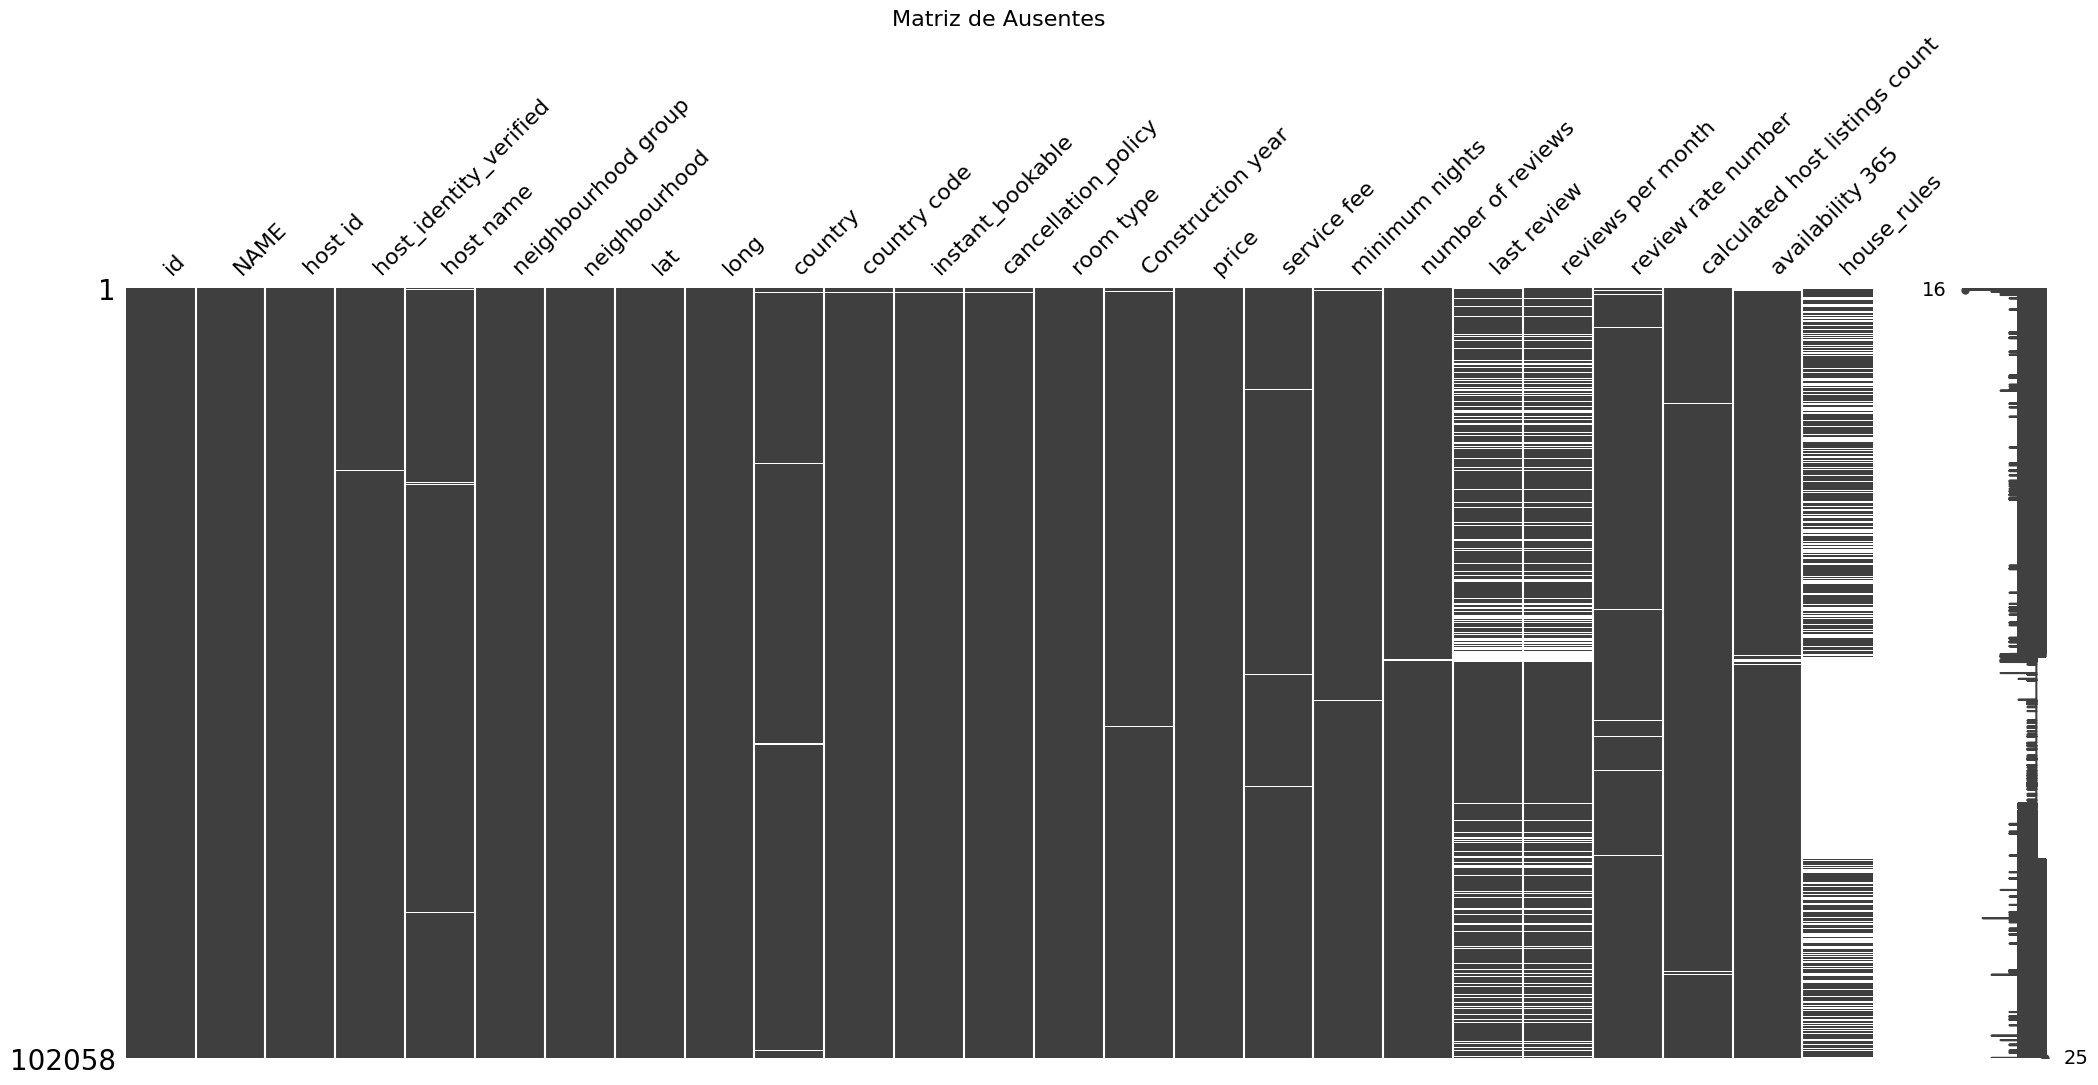


Generando Gráfico de Barras de Nulos...


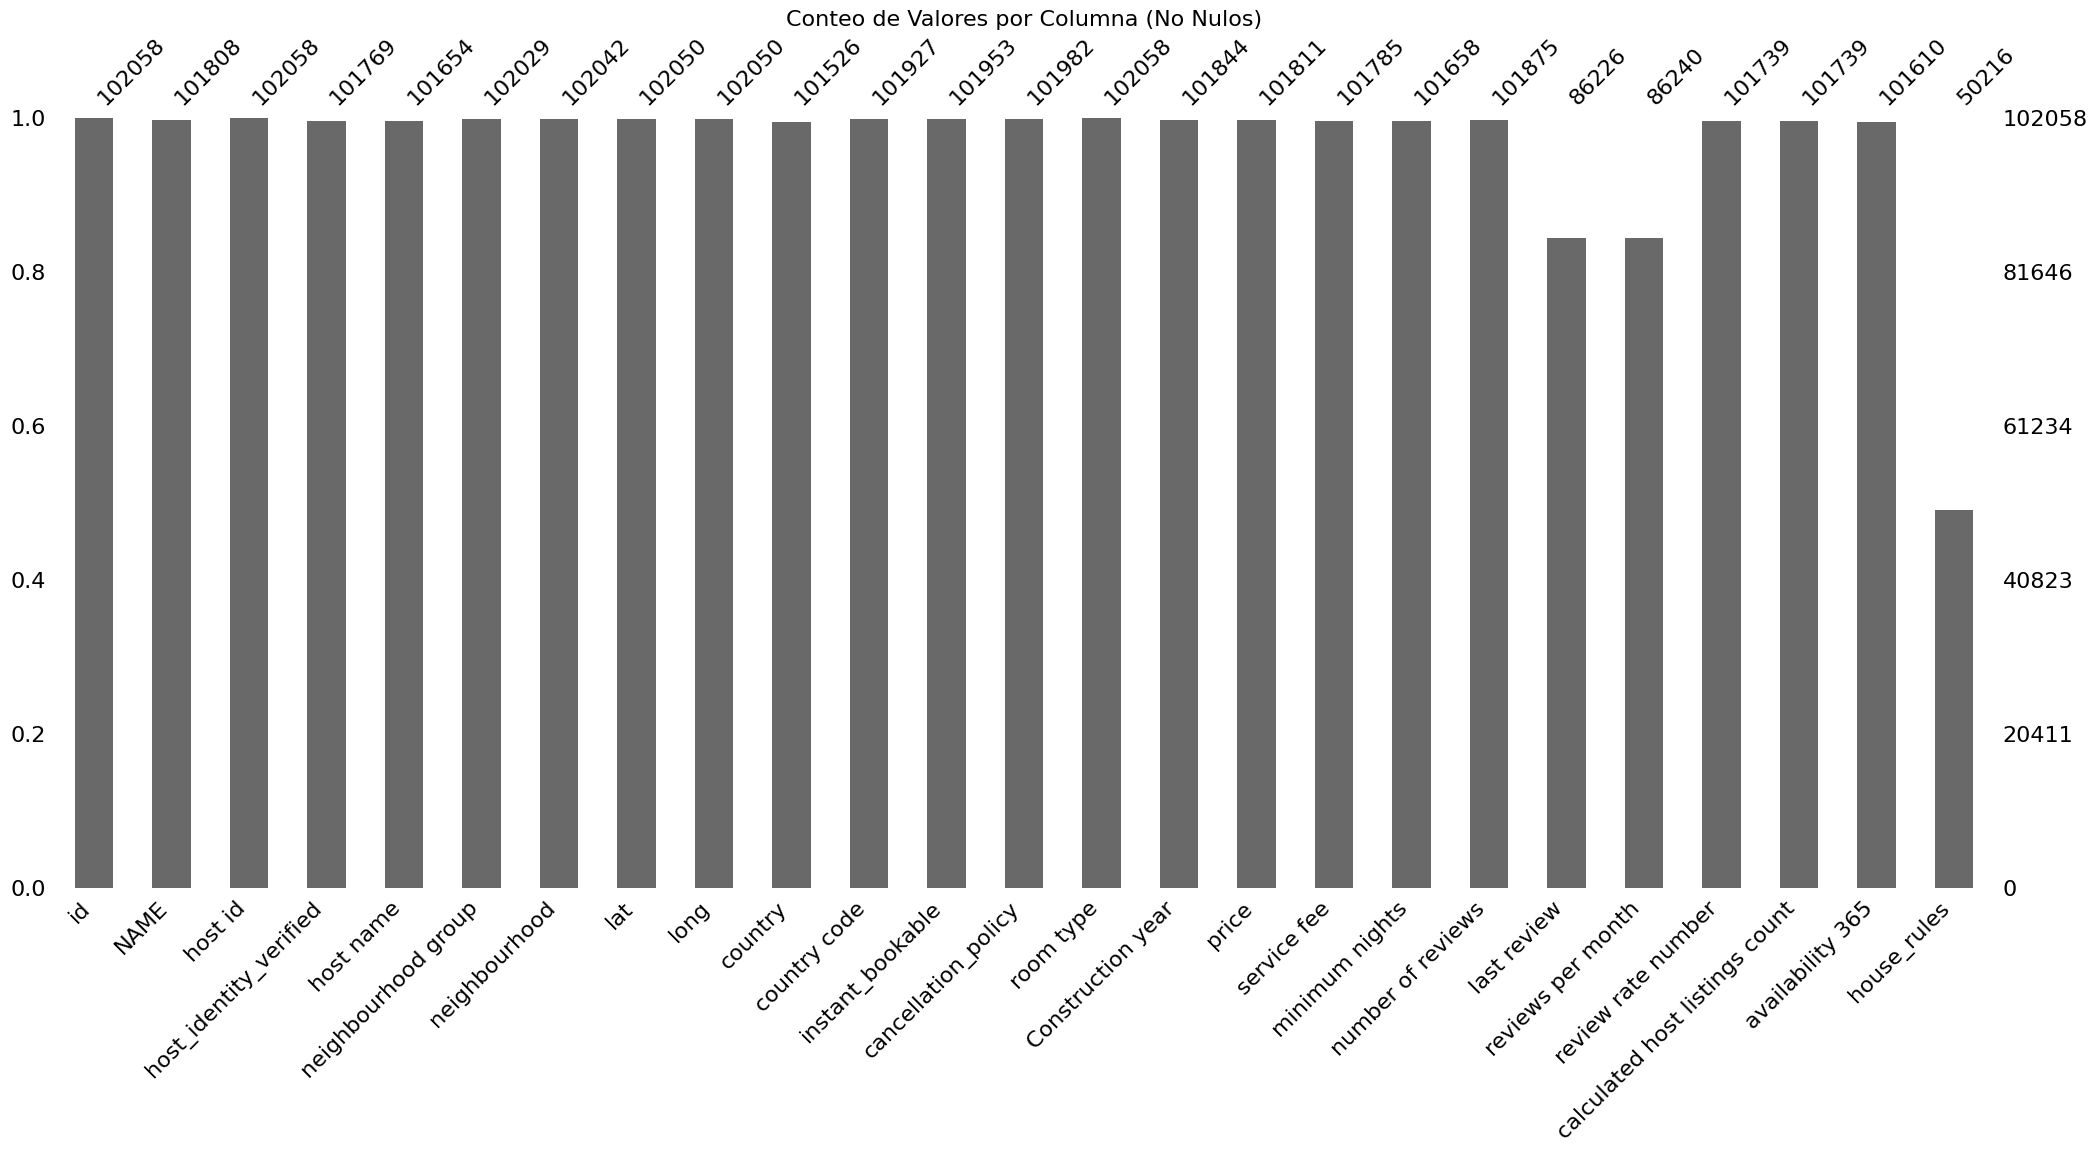

In [25]:
# --- PASO 2: INSPECCIÓN Y LIMPIEZA INICIAL (DUPLICADOS Y NULOS) ---

# Importamos las librerías necesarias para la visualización de nulos
import missingno as msno
import matplotlib.pyplot as plt

print("--- 1. ANÁLISIS DE DATOS DUPLICADOS ---")
# 1.1 Contar cuántos duplicados existen
num_duplicados_inicial = df.duplicated().sum()
print(f"Número de filas duplicadas encontradas: {num_duplicados_inicial}")

# 1.2 Si existen duplicados, visualizamos algunos de ellos antes de eliminar
if num_duplicados_inicial > 0:
    print("\nMostrando algunas de las filas duplicadas:")
    display(df[df.duplicated()].head()) # .head() para no llenar la pantalla si son muchos

# 1.3 Eliminamos las filas duplicadas para evitar sesgos en el análisis
print("\nEliminando filas duplicadas...")
df.drop_duplicates(inplace=True)
print(f"Se eliminaron {num_duplicados_inicial} filas. Verificando...")
print(f"Número de duplicados restantes: {df.duplicated().sum()}")


print("\n\n--- 2. LIMPIEZA DE COLUMNAS INNECESARIAS ---")
# 2.1 Eliminamos la columna 'license' por estar casi completamente vacía
print("Eliminando la columna 'license'...")
df.drop(['license'], axis=1, inplace=True)

# 2.2 Verificamos la ejecución imprimiendo las columnas restantes
print("\nColumnas del DataFrame después de la eliminación:")
print(df.columns)


print("\n\n--- 3. ANÁLISIS DE VALORES NULOS (MISSING VALUES) ---")
# 3.1 Chequeo de Nulos: Conteo por columna
print("\nConteo de valores nulos por columna:")
print(df.isna().sum())

# 3.2 Porcentaje de Nulos: Ordenado de mayor a menor para ver las columnas más problemáticas
print("\nPorcentaje de valores nulos por columna (%):")
print((df.isna().sum() / df.shape[0] * 100).sort_values(ascending=False))

# 3.3 Nulos Totales: Una métrica general de la cantidad de datos faltantes
print("\n-------------------------------------------------")
print(f"Total de celdas con datos nulos en el DataFrame: {df.isna().sum().sum()}")
print("-------------------------------------------------")


print("\n\n--- 4. VISUALIZACIÓN DE VALORES NULOS ---")
# 4.1 Matriz de Nulos: Permite ver patrones de ausencia. Las líneas blancas son datos faltantes.
print("Generando Matriz de Ausentes...")
msno.matrix(df)
plt.title('Matriz de Ausentes', fontsize=16)
plt.show()

# 4.2 Gráfico de Barras de Nulos: Muestra un conteo de los valores no nulos por columna.
print("\nGenerando Gráfico de Barras de Nulos...")
msno.bar(df)
plt.title('Conteo de Valores por Columna (No Nulos)', fontsize=16)
plt.show()

# **3- Imputaciones**

In [26]:
# --- PASO 3: IMPUTACIONES ---

# Imputar 0 en review per month
df['reviews per month']=df['reviews per month'].fillna(0)
df['reviews per month']=df['reviews per month'].fillna(0)
df['number of reviews']=df['number of reviews'].fillna(0)
df['reviews per month']=df['reviews per month'].fillna(0)
df['review rate number']=df['review rate number'].fillna(0)
df['calculated host listings count']=df['calculated host listings count'].fillna(0)
df['lat']=df['lat'].fillna(0)
df['long']=df['long'].fillna(0)

# Imputar 'No review' en last review
df['last review']=df['last review'].fillna('No review')

# Imputar 'Unnamed' en NAME
df['NAME']=df['NAME'].fillna('Unnamed')
df['host name']=df['host name'].fillna('Unnamed')

# Imputar 'unconfirmed' en host_identity_verified
df['host_identity_verified']=df['host_identity_verified'].fillna('unconfirmed')

# Imputar 'Lacks' en country code
df['country code']=df['country code'].fillna('Lacks')

# Imputar 'Unspecified' en neighbourhood group, neighbourhood, country, instant_bookable, cancellation_policy, price, service fee, house_rules
df['neighbourhood group']=df['neighbourhood group'].fillna('Unspecified')
df['neighbourhood']=df['neighbourhood'].fillna('Unspecified')
df['country']=df['country'].fillna('Unspecified')
df['instant_bookable']=df['instant_bookable'].fillna('Unspecified')
df['cancellation_policy']=df['cancellation_policy'].fillna('Unspecified')
df['price']=df['price'].fillna('Unspecified')
df['service fee']=df['service fee'].fillna('Unspecified')
df['house_rules']=df['house_rules'].fillna('Unspecified')
df['Construction year']=df['Construction year'].fillna('Unspecified')
df['minimum nights']=df['minimum nights'].fillna('Unspecified')
df['availability 365']=df['availability 365'].fillna('Unspecified')

# Correccion de Nombres
correcciones = {
    'Brookln': 'Brooklyn',
    'Manhatan': 'Manhattan'
}

# Reemplazamos las variantes con las correcciones
df['neighbourhood group'] = df['neighbourhood group'].replace(correcciones)

# **4- Chequeo de Nulos**

In [27]:
# --- PASO 4: Nulos ---

# Nulos Totales
print("Datos Nulos Restantes:", df.isna().sum().sum())

Datos Nulos Restantes: 0


# **5- Limpieza de datos**

In [28]:
# --- PASO 5: LIMPIEZA DE DATOS ---

# Función segura para limpiar y convertir a float
def limpiar_precio(valor):
    if isinstance(valor, str):
        valor = valor.replace('$', '').replace(',', '').strip()
        try:
            return float(valor)
        except ValueError:
            return None  # Si no puede convertirse, lo deja como NaN
    return valor

# Aplicar a las columnas de precios
df['price'] = df['price'].apply(limpiar_precio)
df['service fee'] = df['service fee'].apply(limpiar_precio)

# Convertir 'last review' a tipo fecha
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

#Limpieza de datos sucios en 'year'
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')
df['year'] = df['last review'].dt.year
print(df['year'].sort_values().unique())
df = df[(df['year'] >= 2016) & (df['year'] <= 2025)]
print(f"Cantidad de registros después del filtrado: {df.shape[0]}")

[2012. 2013. 2014. 2015. 2016. 2017. 2018. 2019. 2020. 2021. 2022. 2024.
 2025. 2026. 2040. 2058.   nan]
Cantidad de registros después del filtrado: 84021


# **6- Cuantos registros 'meses' hay por año**

In [29]:
# --- PASO 6: REGISTROS ---

#Convertir 'availability 365' en numeros
df.loc[:, 'availability 365'] = pd.to_numeric(df['availability 365'], errors='coerce')

# Cuantos registros 'meses' hay por año
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

df_filtered = df.loc[(df['last review'].dt.year >= 2016) & (df['last review'].dt.year <= 2025)].copy()
df_filtered['year'] = df_filtered['last review'].dt.year
df_filtered['month'] = df_filtered['last review'].dt.month
conteo_meses = df_filtered.groupby(['year', 'month']).size().reset_index()
conteo_meses_anuales = conteo_meses.groupby('year')['month'].nunique()

conteo_meses_anuales



,month
year,
2016,12
2017,12
2018,12
2019,7
2020,11
2021,12
2022,5
2024,1
2025,1


## **7- Separacion de columnas en numéricas y categoricas**

In [30]:
# --- PASO 7: COLUMNAS ---

# Columnas numéricas y categoricas
def separar_columnas(df):
  columnas_numericas=df.select_dtypes(include='number').columns
  columnas_categoricas = df.select_dtypes(include=['object', 'category']).columns
  return columnas_numericas, columnas_categoricas

columnas_numericas, columnas_categoricas = separar_columnas(df)
print("Columnas numéricas:", columnas_numericas)
print("Columnas categóricas:", columnas_categoricas)

Columnas numéricas: Index(['id', 'host id', 'lat', 'long', 'price', 'service fee',
       'number of reviews', 'reviews per month', 'review rate number',
       'calculated host listings count', 'year'],
      dtype='object')
Columnas categóricas: Index(['NAME', 'host_identity_verified', 'host name', 'neighbourhood group',
       'neighbourhood', 'country', 'country code', 'instant_bookable',
       'cancellation_policy', 'room type', 'Construction year',
       'minimum nights', 'availability 365', 'house_rules'],
      dtype='object')


# **8- Variables Numericas**

In [31]:
# --- PASO 8: VARIABLES NUMERICA ---

# Variables Numericas
df.describe()

,id,host id,lat,long,price,service fee,number of reviews,last review,reviews per month,review rate number,calculated host listings count,year
count,8.402100e+04,8.402100e+04,84021.000000,84021.000000,83805.000000,83783.000000,84021.000000,84021,84021.000000,84021.000000,84021.000000,84021.000000
mean,2.989302e+07,4.921983e+10,40.724993,-73.943823,626.175109,125.197594,33.222849,2019-07-19 01:40:26.950405120,1.409695,3.275324,7.154259,2019.104724
min,1.001254e+06,1.236005e+08,0.000000,-74.249840,50.000000,10.000000,0.000000,2016-01-01 00:00:00,0.000000,0.000000,0.000000,2016.000000
25%,1.599076e+07,2.455577e+10,40.687590,-73.982070,341.000000,68.000000,3.000000,2018-12-10 00:00:00,0.240000,2.000000,1.000000,2018.000000
50%,3.103154e+07,4.909114e+10,40.721380,-73.953540,625.000000,125.000000,12.000000,2019-06-15 00:00:00,0.780000,3.000000,1.000000,2019.000000
75%,4.362509e+07,7.388269e+10,40.762720,-73.930450,914.000000,183.000000,40.000000,2019-07-06 00:00:00,2.060000,4.000000,2.000000,2019.000000
max,5.736742e+07,9.876313e+10,40.916970,0.000000,1200.000000,240.000000,1024.000000,2025-06-26 00:00:00,90.000000,5.000000,332.000000,2025.000000
std,1.610676e+07,2.852069e+10,0.319216,0.572683,331.572660,66.308981,52.794917,NaN,1.757832,1.291265,29.741184,1.532173


# **9- Variables Categoricas**

In [32]:
# --- PASO 9: VARIABLES CATEGORICA ---

# Variables Categoricas
df[columnas_categoricas].describe()

,NAME,host_identity_verified,host name,neighbourhood group,neighbourhood,country,country code,instant_bookable,cancellation_policy,room type,Construction year,minimum nights,availability 365,house_rules
count,84021,84021,84021,84021,84021,84021,84021,84021,84021,84021,84021.0,84021.0,83847.0,84021
unique,50283,2,11529,8,224,2,2,3,4,4,21.0,131.0,438.0,1950
top,Unnamed,unconfirmed,Michael,Brooklyn,Bedford-Stuyvesant,United States,US,False,moderate,Entire home/apt,2014.0,2.0,0.0,Unspecified
freq,203,42186,720,34778,6830,83537,83910,42182,28140,44419,4321.0,20875.0,17813.0,44304


# **10- Agrupación de Tiempo**

In [33]:
# --- PASO 10: TIEMPO ---

# Año, Mes, Trimestre
df.loc[:, 'last review'] = pd.to_datetime(df['last review'])
df.loc[:, 'year'] = df['last review'].dt.year
df.loc[:, 'month'] = df['last review'].dt.month
df.loc[:, 'quarter'] = df['last review'].dt.quarter
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,year,month,quarter
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,2021.0,10,4
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,2022.0,5,2
3,1002755,Unnamed,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,270.0,2019-07-05,4.64,4.0,1.0,322.0,Unspecified,2019.0,7,3
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",2018.0,11,4
5,1004098,Large Cozy 1 BR Apartment In Midtown East,45498551794,verified,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,United States,...,74.0,2019-06-22,0.59,3.0,1.0,374.0,"No smoking, please, and no drugs.",2019.0,6,2


# **Parte 2: Visualizaciones Exploratorias Generales**

## **1- Distribución de tipo de habitación *(room type)***

Gráfico de barras → ***ver qué tipo de habitación es más ofrecido*** *(entero, privado, compartido).*

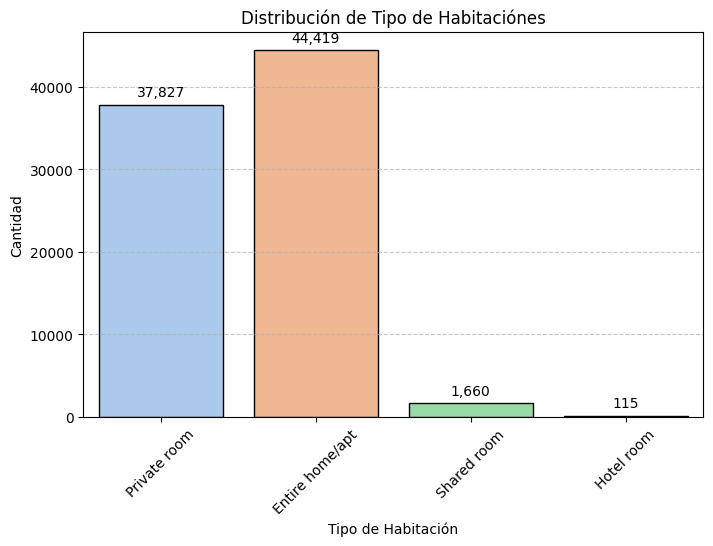

In [34]:
# --- PASO 1: DISTRIBUCIÓN DE TIPO DE HABITACIÓN ---

#Estetica Grafico de Barras:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='room type', hue='room type', palette='pastel',edgecolor='black')

# Agregar % sobre las barras:
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():,.0f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       fontsize=10, color='black',
                       xytext=(0, 9), textcoords='offset points')

#Grid y estilo:
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.title('Distribución de Tipo de Habitaciónes')
plt.xlabel('Tipo de Habitación')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

# **2- Distribución de tipo de habitación (room type)**

Gráfico de Torta → ***ver qué tipo de habitación es más ofrecido (entero, privado, compartido).***

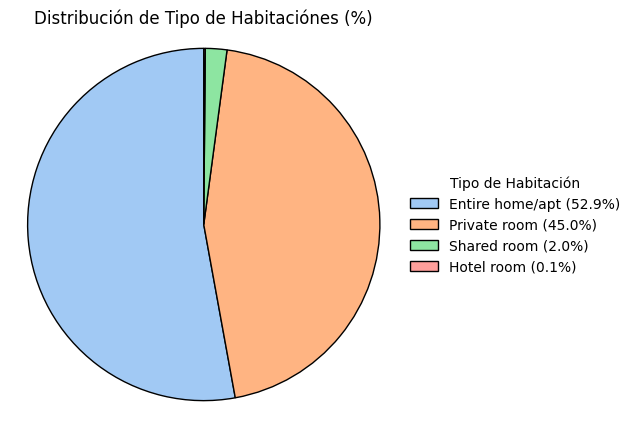

In [35]:
# --- PASO 2: DISTRIBUCIÓN DE TIPO DE HABITACIÓN ---

# Distribución de tipo de habitación
conteo_tipo_de_habitacion = df['room type'].value_counts()

# Calculo de %
percentages = conteo_tipo_de_habitacion / conteo_tipo_de_habitacion.sum() * 100

# Estética Gráfico de barras
color=sns.color_palette('pastel', n_colors=len(conteo_tipo_de_habitacion))
plt.figure(figsize=(5,5))
plt.pie(conteo_tipo_de_habitacion,
         labels=None,
        colors=color,
        startangle=90,
        wedgeprops={'edgecolor': 'black'})

# Ajustar el gráfico
plt.title('Distribución de Tipo de Habitaciónes (%)')
labels = [f'{i} ({j:.1f}%)' for i, j in zip(conteo_tipo_de_habitacion.index, percentages)]
plt.legend(labels,
           loc='center left',
           bbox_to_anchor=(1, 0.5),
           title='Tipo de Habitación',
           frameon=False)
plt.axis('equal')
plt.show()


# **3- Cantidad de alojamientos por barrio (neighbourhood group o neighbourhood)**

Gráfico de barras → ***¿Dónde se concentra la mayoría de los alojamientos?***

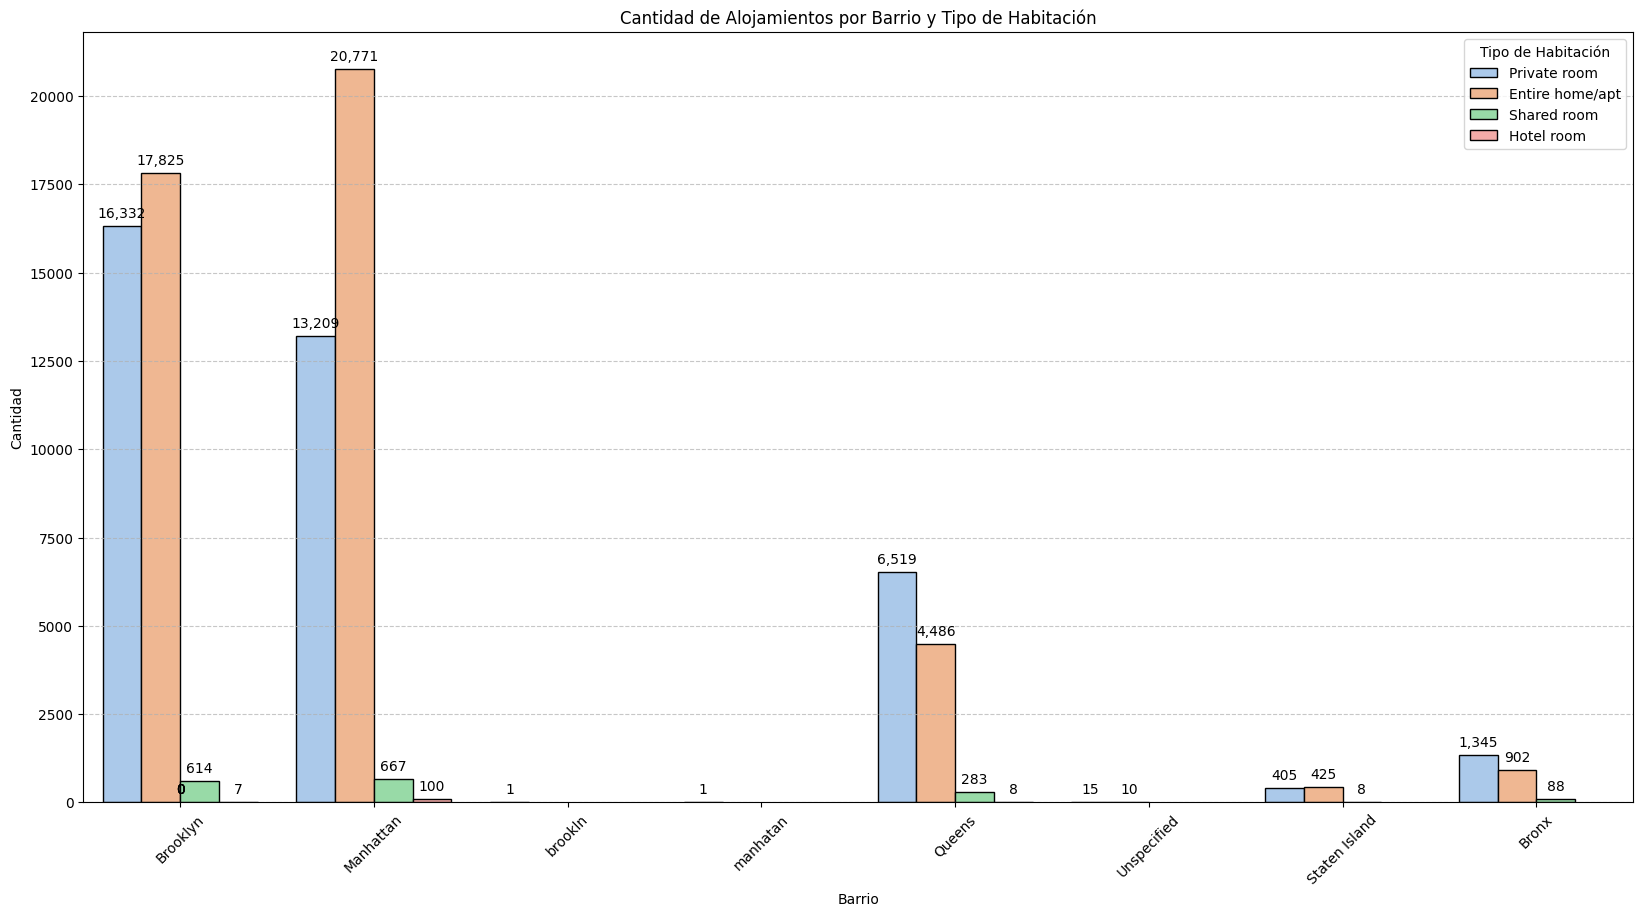

In [36]:
# --- PASO 3: CANTIDAD DE ALOJAMIENTO POR BARRIO ---

#Estetica Grafico de barras
plt.figure(figsize=(20,10))
sns.countplot(data=df, x='neighbourhood group', hue='room type', palette='pastel', edgecolor='black')

# Agregar % sobre las barras
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():,.0f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       fontsize=10, color='black',
                       xytext=(0, 9), textcoords='offset points')

#Grid y estilo
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.title('Cantidad de Alojamientos por Barrio y Tipo de Habitación')
plt.xlabel('Barrio')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.legend(title='Tipo de Habitación')
plt.show()

# **4- Cantidad de alojamientos por barrio (neighbourhood group o neighbourhood)**

Gráfico de Torta → ***¿Dónde se concentra la mayoría de los alojamientos?***

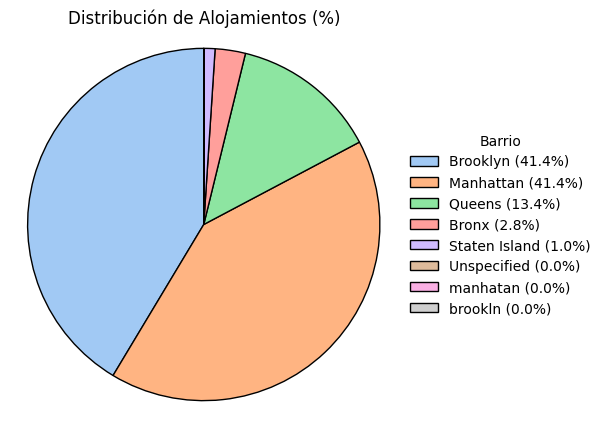

In [37]:
# --- PASO 4: CANTIDAD DE ALOJAMIENTO POR BARRIO ---

# % de Distribución de alojamientos
conteo_de_barrios = df['neighbourhood group'].value_counts()

# Calculo de %
percentages = conteo_de_barrios / conteo_de_barrios.sum() * 100

# Estética Gráfico de barras
color=sns.color_palette('pastel', n_colors=len(conteo_de_barrios))
plt.figure(figsize=(5,5))
plt.pie(conteo_de_barrios,
        labels=None,
        colors=color,
        startangle=90,
        wedgeprops={'edgecolor': 'black'})

# Ajustar el gráfico
plt.title('Distribución de Alojamientos (%)')
labels = [f'{i} ({j:.1f}%)' for i, j in zip(conteo_de_barrios.index, percentages)]
plt.legend(labels,
           loc='center left',
           bbox_to_anchor=(1, 0.5),
           title='Barrio',
           frameon=False)
plt.axis('equal')
plt.show()

# **5- Disponibilidad (availability 365)**

Histograma → ***¿Cuántos alojamientos están disponibles todo el año? ¿Cuántos tienen poca disponibilidad?***


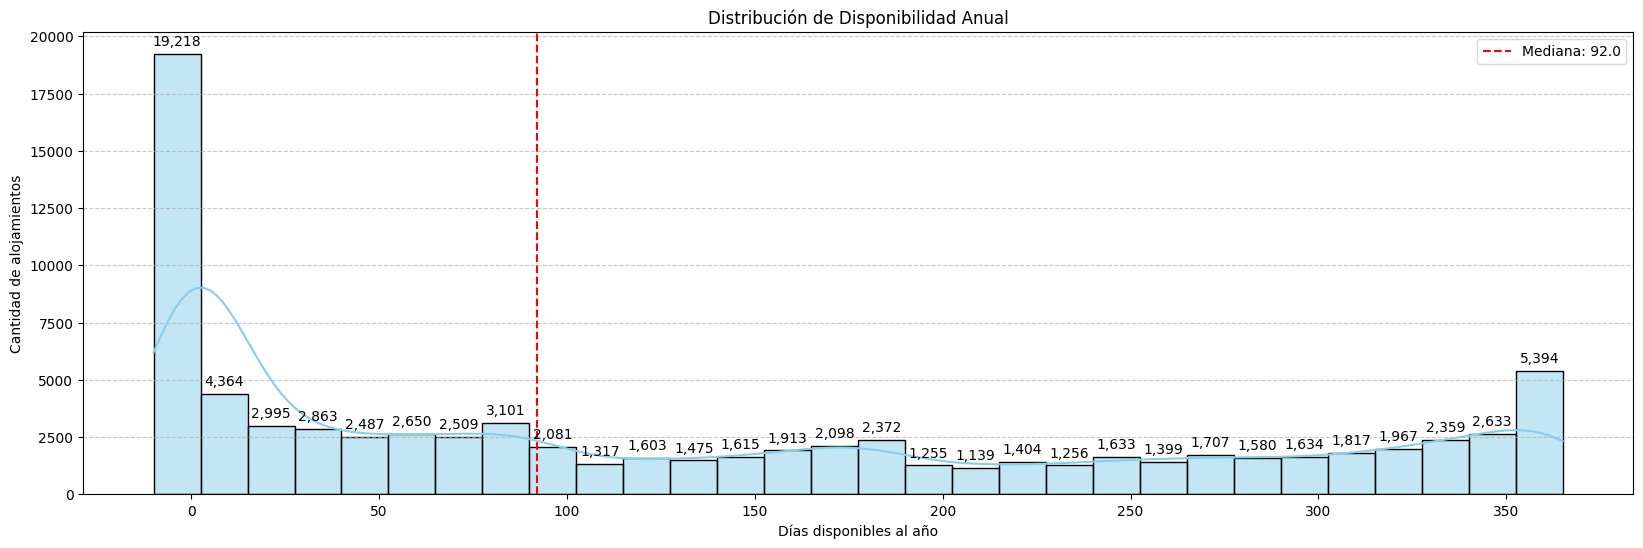

In [38]:
# --- PASO 5: DISPONIBILIDAD ---

# Filtro solo alojamiento con disponibilidad entre 0 y 365 dias
df_filtered = df[df['availability 365'] <= 365]

#Estetica de Histograma
plt.figure(figsize=(20,6))
sns.histplot(data=df_filtered, x='availability 365', bins=30, kde=True, color='skyblue', edgecolor='black')
plt.axvline(df_filtered['availability 365'].median(), color='red', linestyle='--', label=f'Mediana: {df_filtered["availability 365"].median()}')
plt.legend()

# Agregar % sobre las barras
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():,.0f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       fontsize=10, color='black',
                       xytext=(0, 9), textcoords='offset points')

#Grid y estilo
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.title('Distribución de Disponibilidad Anual')
plt.xlabel('Días disponibles al año')
plt.ylabel('Cantidad de alojamientos')
plt.show()

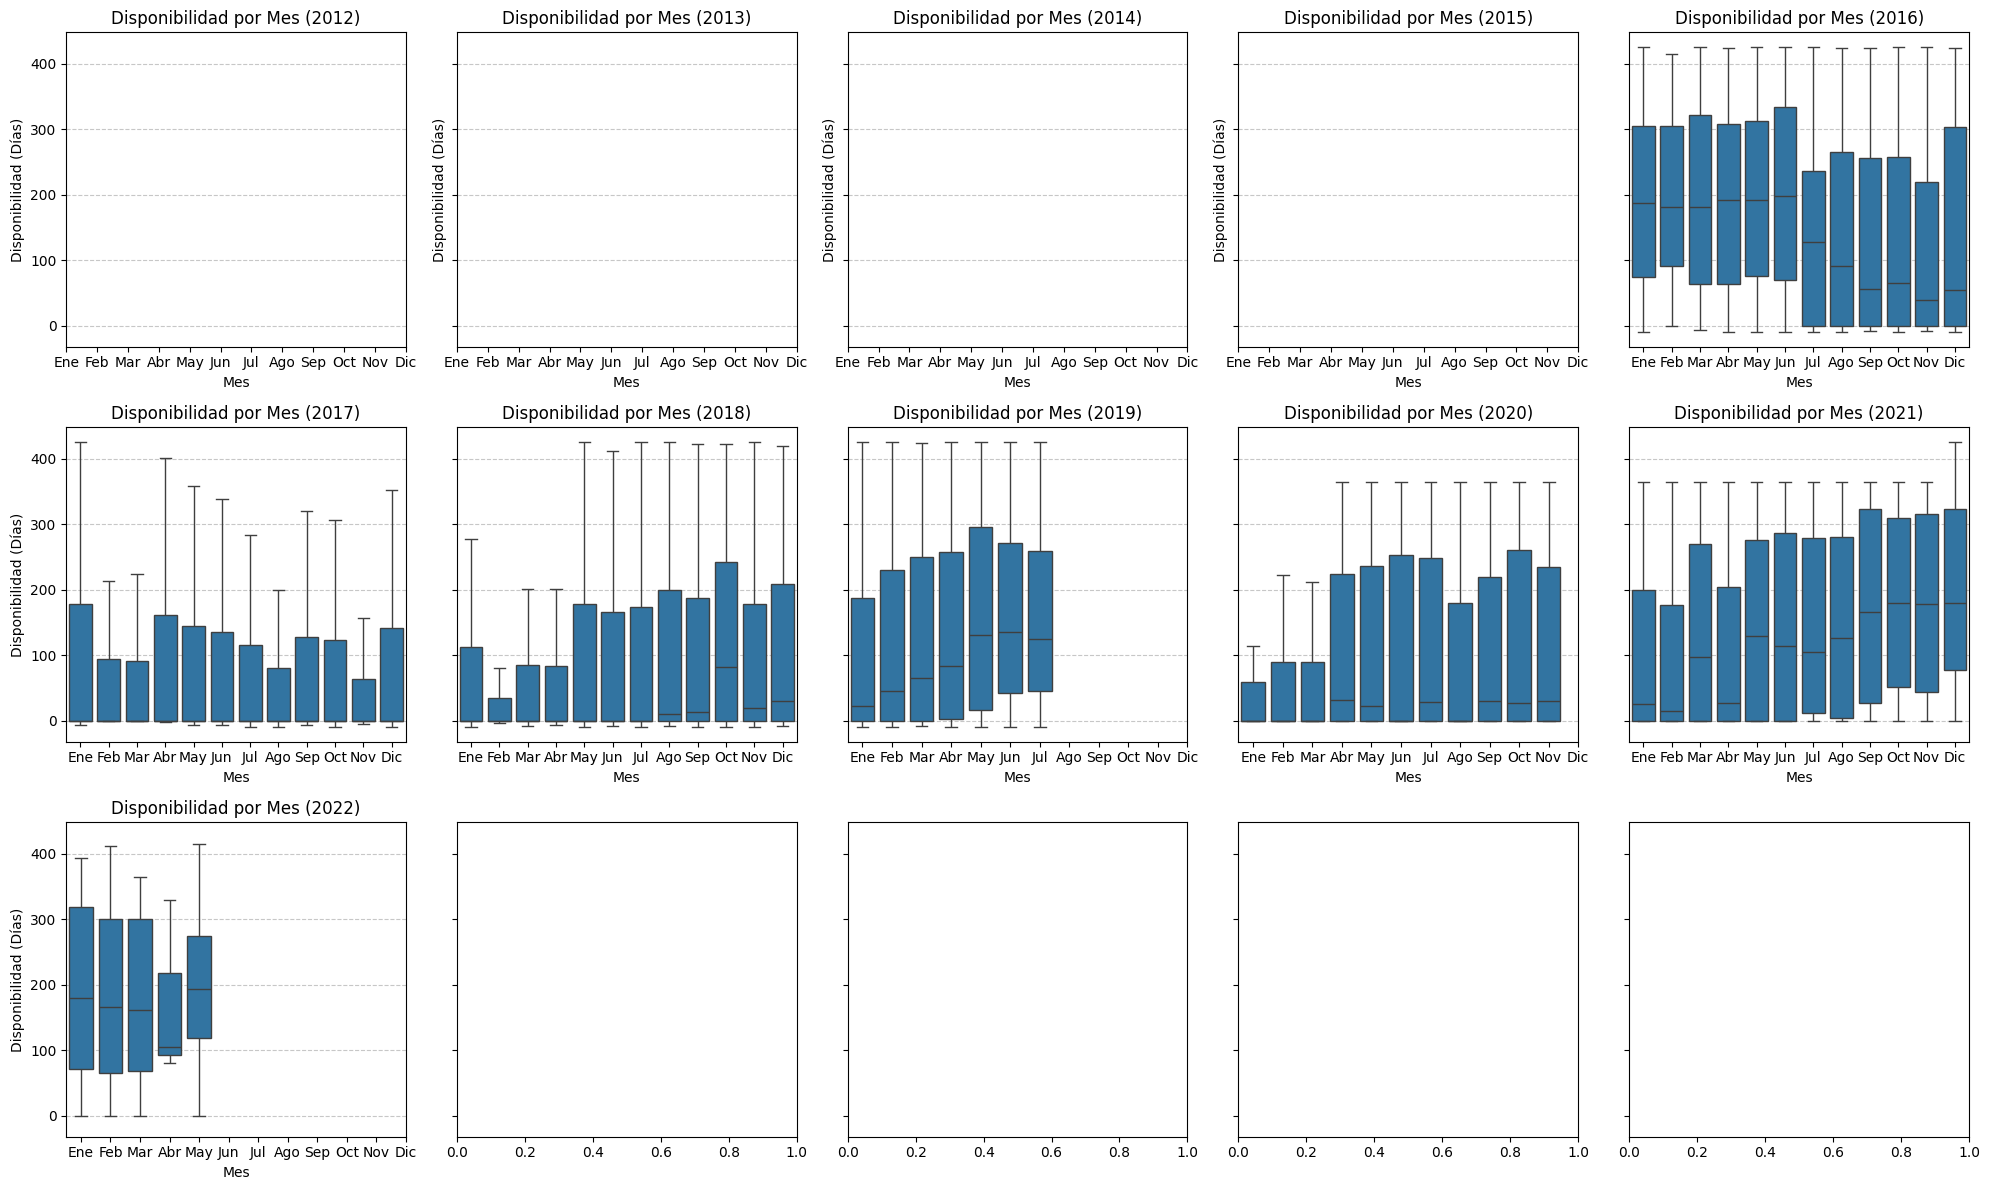

In [39]:
# --- PASO 6: LISTA DE LOS AÑOS QUE SE VISUALIZARAN---

# Lista de los años que se Visualizaran
years = [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

# Subgráficos de 3 filas y 5 columnas (para cubrir todos los años)
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 12), sharey=True)

# Aplanar la matriz de ejes para facilitar la iteración
axes = axes.flatten()

# Grafico por año
for i, year in enumerate(years):
    ax = axes[i]

    # Filtrar los datos para el año específico
    df_year = df[df['year'] == year]

    # Gráfico de barras para mostrar la disponibilidad de los alojamientos por mes para ese año
    sns.boxplot(data=df_year, x='month', y='availability 365', ax=ax, showfliers=False)

    #Grid y estilo
    ax.set_title(f'Disponibilidad por Mes ({year})')
    ax.set_xlabel('Mes')
    ax.set_ylabel('Disponibilidad (Días)')
    ax.set_xticks(range(12))
    ax.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Espacio entre Graficos
plt.tight_layout()

plt.show()

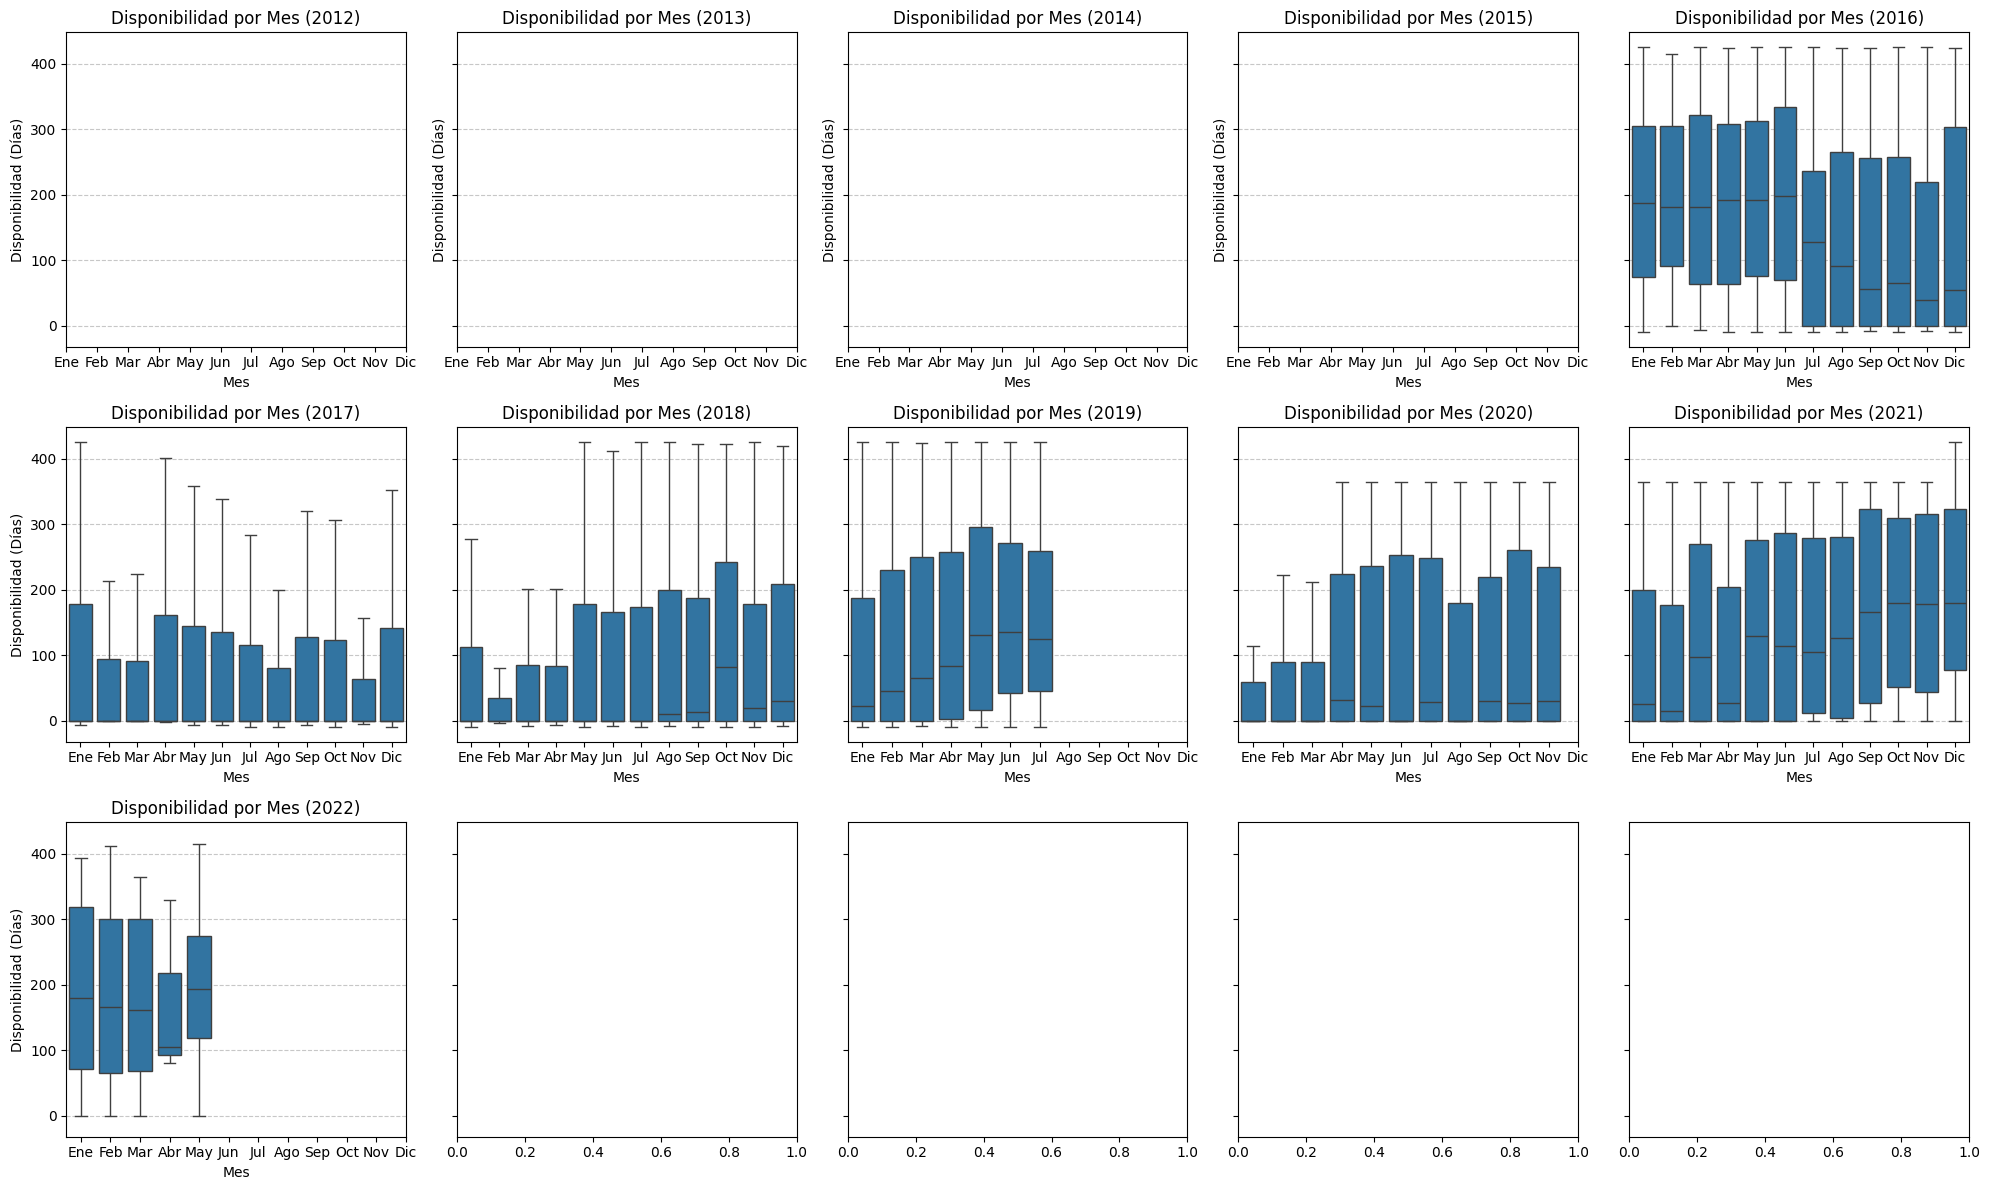

In [40]:
# --- PASO 7: LISTA DE LOS AÑOS QUE SE VISUALIZARAN---

# Lista de los años que se Visualizaran
years = [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

# Subgráficos de 3 filas y 5 columnas (para cubrir todos los años)
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 12), sharey=True)

# Aplanar la matriz de ejes para facilitar la iteración
axes = axes.flatten()

# Grafico por año
for i, year in enumerate(years):
    ax = axes[i]

    # Filtrar los datos para el año específico
    df_year = df[df['year'] == year]

    # Gráfico de barras para mostrar la disponibilidad de los alojamientos por mes para ese año
    sns.boxplot(data=df_year, x='month', y='availability 365', ax=ax, showfliers=False)

    #Grid y estilo
    ax.set_title(f'Disponibilidad por Mes ({year})')
    ax.set_xlabel('Mes')
    ax.set_ylabel('Disponibilidad (Días)')
    ax.set_xticks(range(12))
    ax.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
    ax.grid(axis='y', linestyle='--', alpha=0.7)

# Espacio entre Graficos
plt.tight_layout()

plt.show()

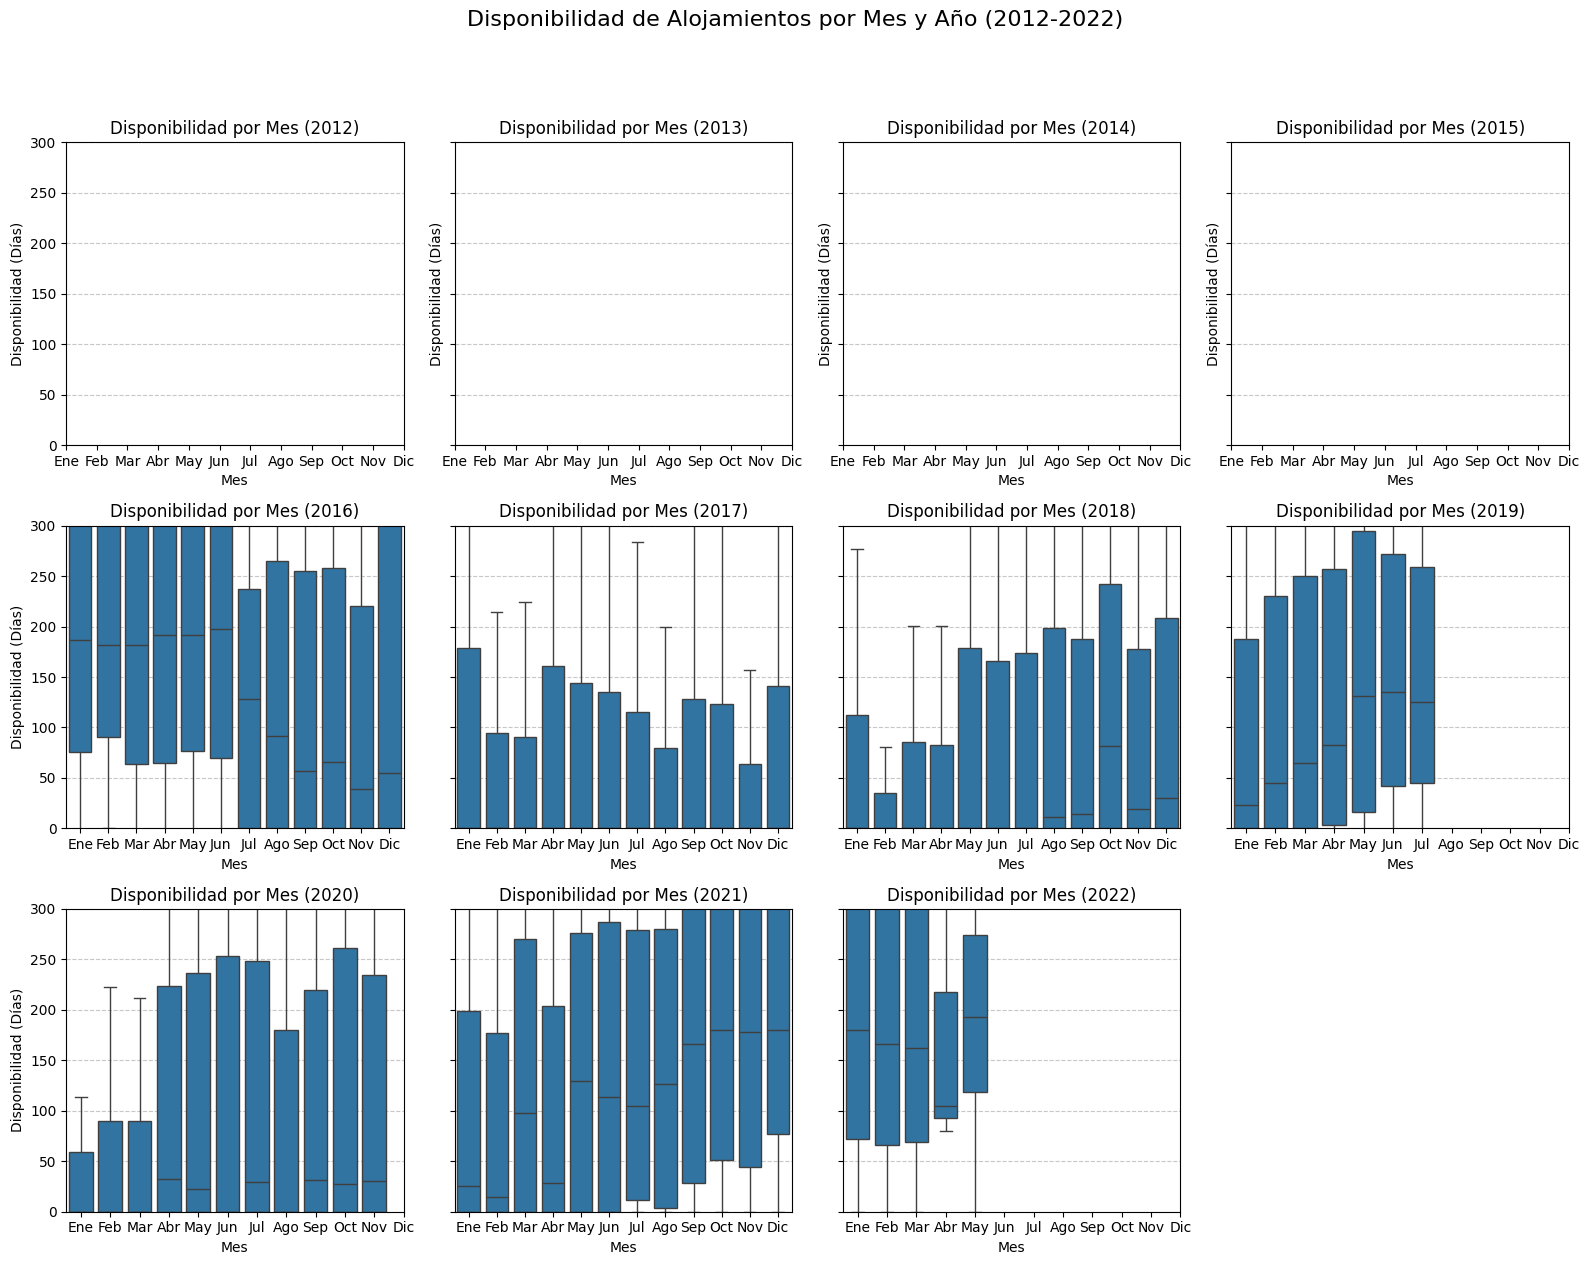

In [41]:
# --- PASO 8: LISTA DE LOS AÑOS QUE SE VISUALIZARAN---

# Lista de los años que se visualizarán
years = [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

# Subgráficos de 3 filas y 4 columnas (para 11 años, dejando solo 1 espacio vacío)
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12), sharey=True)

# Aplanar la matriz de ejes para facilitar la iteración
axes = axes.flatten()

# Grafico por año
for i, year in enumerate(years):
    ax = axes[i]

    # Filtrar los datos para el año específico
    df_year = df[df['year'] == year]

    # Gráfico de barras para mostrar la disponibilidad de los alojamientos por mes para ese año
    sns.boxplot(data=df_year, x='month', y='availability 365', ax=ax, showfliers=False)

    # Grid y estilo
    ax.set_title(f'Disponibilidad por Mes ({year})')
    ax.set_xlabel('Mes')
    ax.set_ylabel('Disponibilidad (Días)')
    ax.set_xticks(range(12))
    ax.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_ylim(0, 300)  # Ajustar el rango del eje Y

    # Ocultar el subgráfico sobrante
    if i == len(years) - 1:
        axes[-1].set_visible(False)

# Título general
fig.suptitle('Disponibilidad de Alojamientos por Mes y Año (2012-2022)', fontsize=16, y=1.05)

# Espacio entre gráficos
plt.tight_layout()

plt.show()

# **6- Relación entre precio y tipo de habitación (price vs room type)**

Boxplot → ***¿Cuál es la variación de precios en cada tipo de alojamiento?***

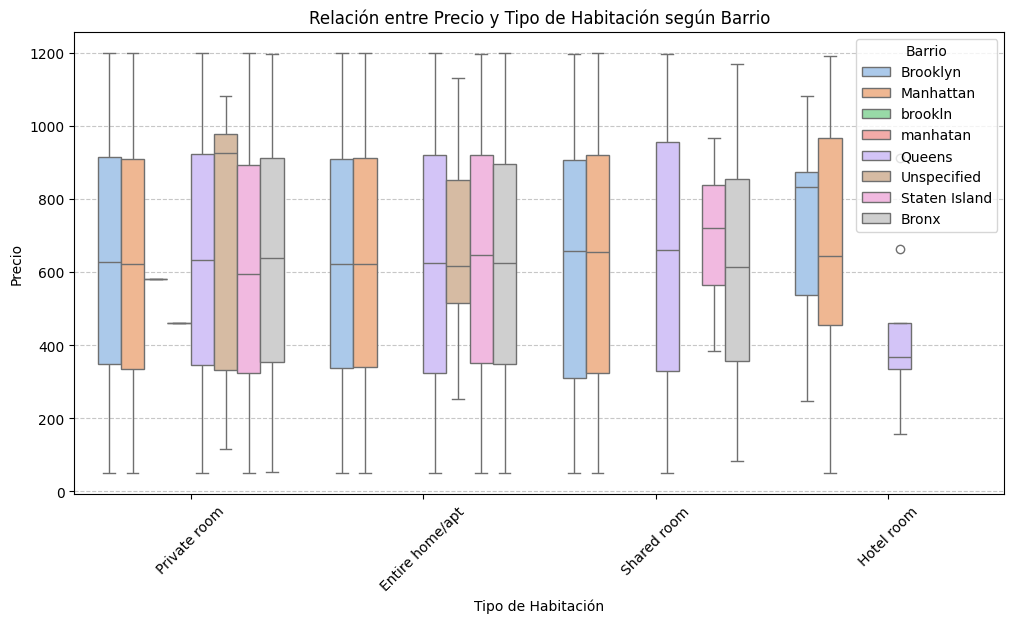

In [42]:
# --- PASO 9: RELACIÓN ENTRE PRECIO Y TIPO DE HABITACIÓN---

#Estetica de Histograma
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='room type', y='price', hue='neighbourhood group', palette='pastel')

#Grid y estilo

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Relación entre Precio y Tipo de Habitación según Barrio')
plt.xlabel('Tipo de Habitación')
plt.ylabel('Precio')
plt.xticks(rotation=45)
plt.legend(title='Barrio')
plt.show()

# **Parte 3- Visualizaciones Comparativas más específicas**

---



Objetivo: ***Buscar relaciones o patrones entre variables.***


# **1- Precio promedio por barrio (neighbourhood group)**

Gráfico de barras → ***¿Qué barrio tiene alojamientos más caros o más baratos?***


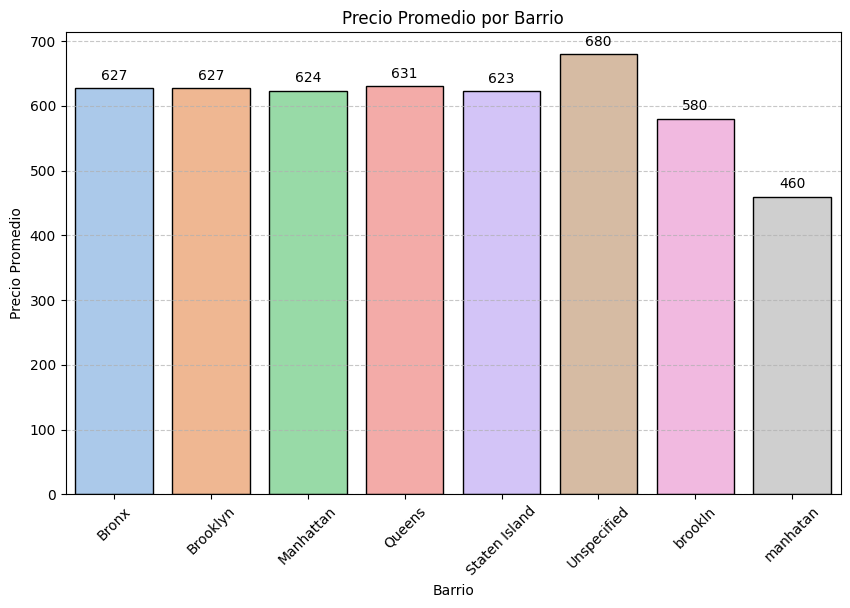

In [43]:
# --- PASO 1: PRECIO PROMEDIO POR BARRIO---

# Agrupamos para calcular precio promedio
precio_promedio_por_barrio = df.groupby('neighbourhood group')['price'].mean().reset_index()

# Estética Grafic de barras
plt.figure(figsize=(10,6))
sns.barplot(data=precio_promedio_por_barrio, x='neighbourhood group', y='price',hue='neighbourhood group', palette='pastel', edgecolor='black')

# Agregar % sobre las barras
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():,.0f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       fontsize=10, color='black',
                       xytext=(0, 9), textcoords='offset points')

# Grid y estilo
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Precio Promedio por Barrio')
plt.xlabel('Barrio')
plt.ylabel('Precio Promedio')
plt.xticks(rotation=45)
plt.show()

# **2- Precio promedio por barrio (neighbourhood group)**

Gráfico de Torta → ***¿Qué barrio tiene alojamientos más caros o más baratos?***


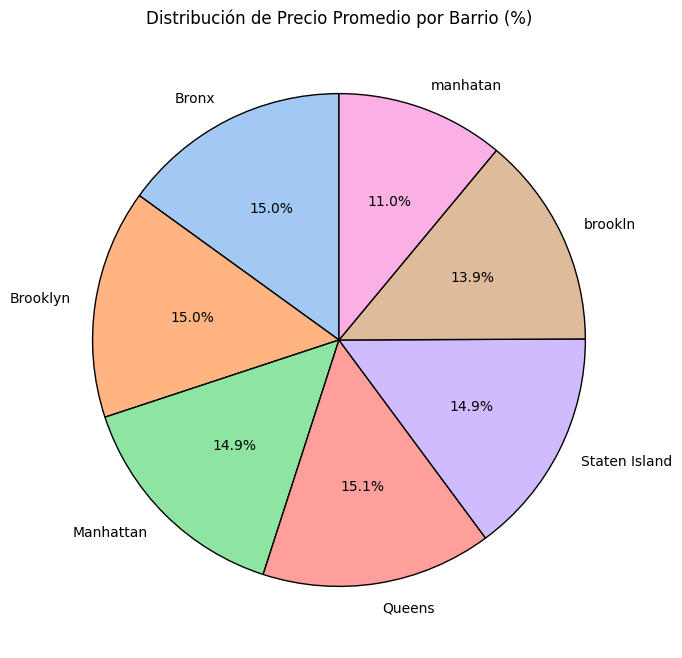

In [44]:
# --- PASO 2: PRECIO PROMEDIO POR BARRIO---

# Filtro para obviar 'Unspecified' de 'neighbourhood group'
df_filtrado = df[df['neighbourhood group'] != 'Unspecified']

# Promedio de precio por barrio
precio_promedio_por_barrio = df_filtrado.groupby('neighbourhood group')['price'].mean().reset_index()

# Distribución % de precios promedio por barrio
plt.figure(figsize=(8,8))
plt.pie(precio_promedio_por_barrio['price'], labels=precio_promedio_por_barrio['neighbourhood group'], autopct='%1.1f%%',
        colors=sns.color_palette('pastel', n_colors=len(precio_promedio_por_barrio)), startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Distribución de Precio Promedio por Barrio (%)')
plt.show()

# **3- Número de reseñas vs. precio (number of reviews vs price)**

Scatterplot → ***¿Los alojamientos más caros tienen más o menos reseñas?***


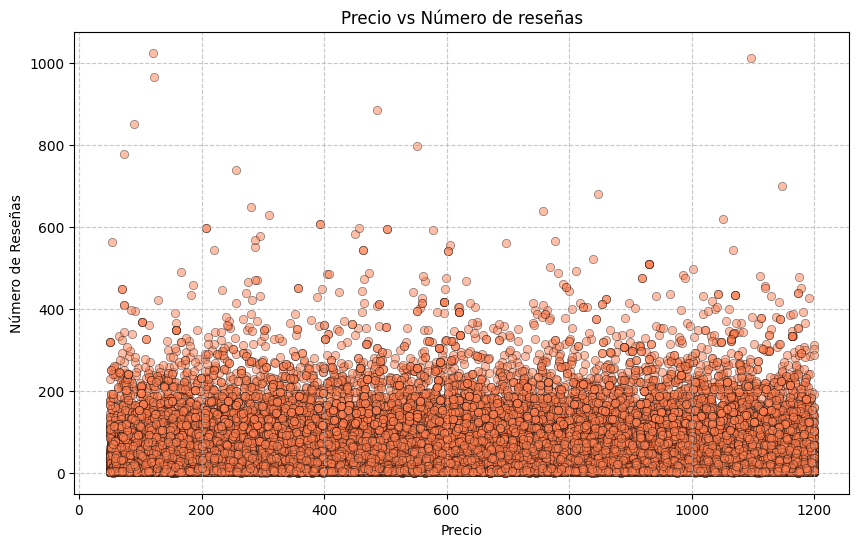

In [45]:
# --- PASO 3: RESEÑA VS PRECIO---

# Estética Scatterplot
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='price', y='number of reviews', alpha=0.5, color='coral', edgecolor='black')
# Grid y estilo
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.title('Precio vs Número de reseñas')
plt.xlabel('Precio')
plt.ylabel('Número de Reseñas')
plt.show()

# **4- Relación entre cantidad de reviews y disponibilidad (number of reviews vs availability 365)**

Scatterplot → ***¿Los alojamientos más disponibles reciben más reviews?***

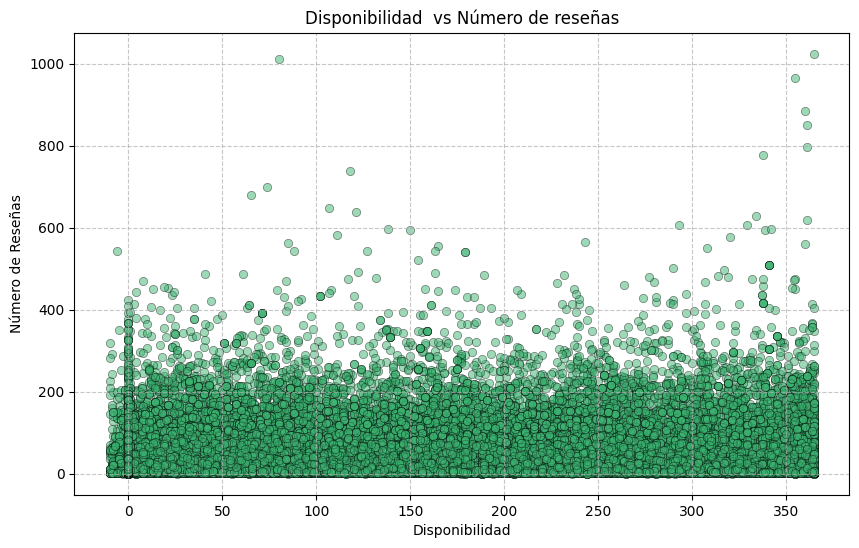

In [46]:
# --- PASO 4: REVIEW VS DISPONIBILIDAD---

# Filtro solo alojamiento con disponibilidad entre 0 y 365 dias
df_filtered = df[df['availability 365'] <= 365]

# Estética Scatterplot
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_filtered, x='availability 365', y='number of reviews', alpha=0.5, color='mediumseagreen', edgecolor='black')

# Grid y estilo
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.title('Disponibilidad  vs Número de reseñas')
plt.xlabel('Disponibilidad')
plt.ylabel('Número de Reseñas')
plt.show()

# **5- Política de cancelación por barrio (neighbourhood group)**

Gráfico de barras → ***Analizar cómo se distribuyen las políticas de cancelación en diferentes barrios.***

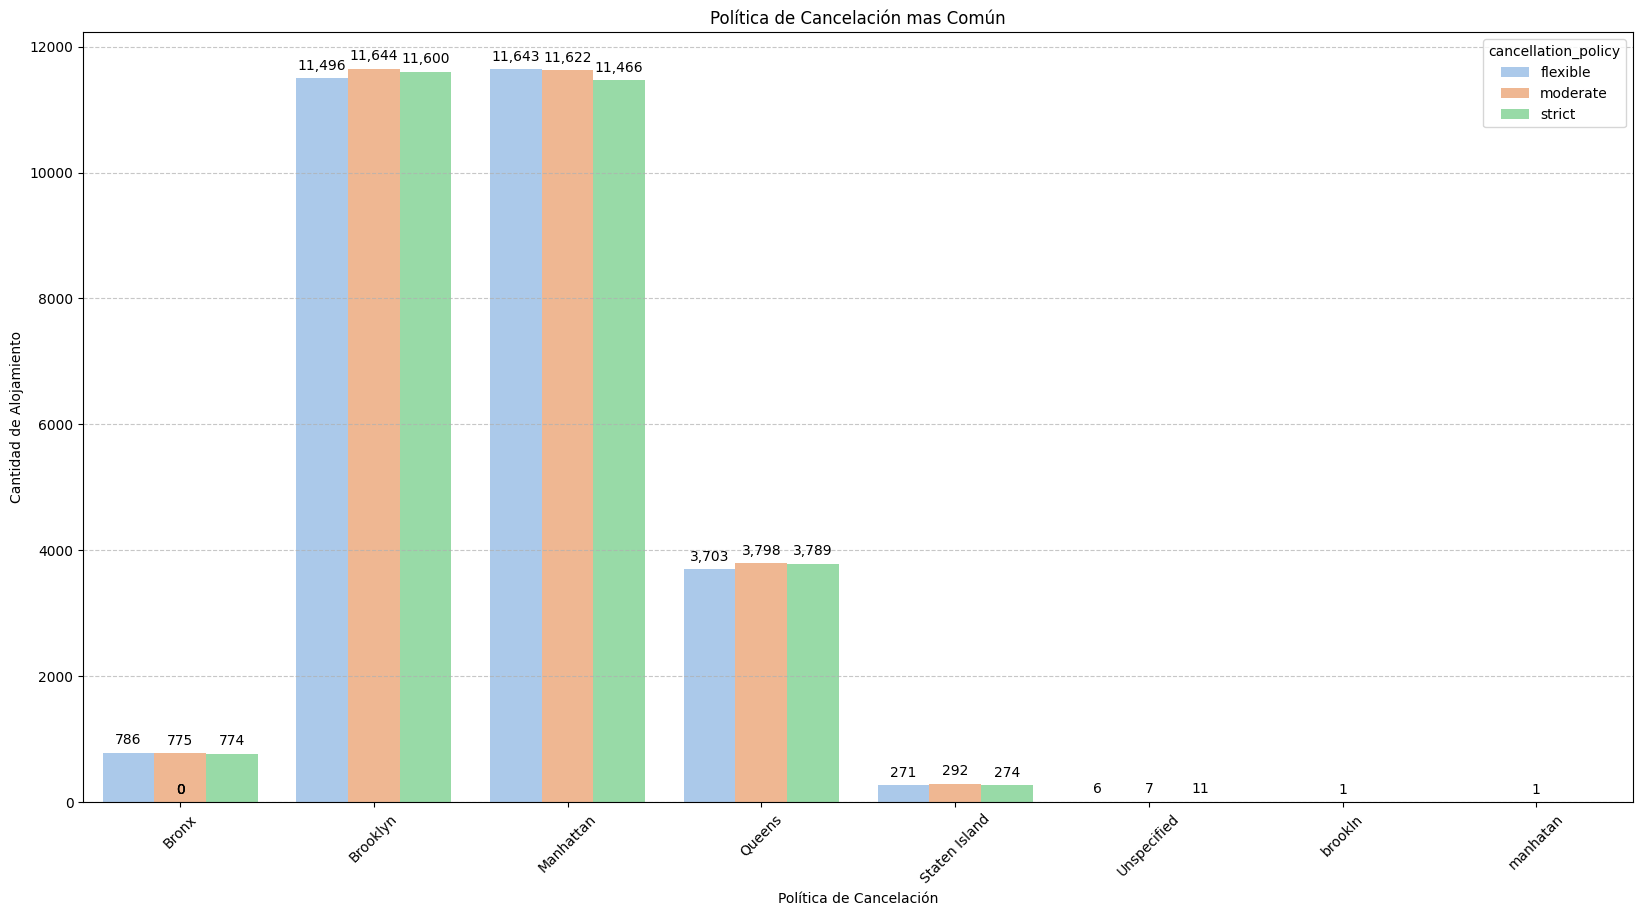

In [47]:
# --- PASO 5: POLÍTICA DE CANCELACIÓN---

# Agrupar por barrio y política de cancelación
política_por_barrio = df[df['cancellation_policy'].isin(['flexible', 'moderate', 'strict'])] \
                      .groupby(['neighbourhood group', 'cancellation_policy']).size().reset_index(name='count')

# Estética Gráfico de barras
plt.figure(figsize=(20,10))
sns.barplot(data=política_por_barrio, x='neighbourhood group', y='count', hue='cancellation_policy', palette='pastel')

# Agregar % sobre las barras
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():,.0f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       fontsize=10, color='black',
                       xytext=(0, 9), textcoords='offset points')

# Grid y estilo
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Política de Cancelación mas Común')
plt.xlabel('Política de Cancelación')
plt.ylabel('Cantidad de Alojamiento')
plt.xticks(rotation=45)
plt.show()


# **Parte 4- Visualizaciones de Calidad de Datos o Análisis Extra**

Objetivo: *Mostrar el impacto de tu limpieza de datos y entender mejor los datos categóricos.*


# **1- Cantidad de alojamientos por estado de verificación del host (host_identity_verified)**

Gráfico de Torta → ***¿Cuántos hosts tienen identidad verificada?***


host_identity_verified
unconfirmed    42186
verified       41835
Name: count, dtype: int64


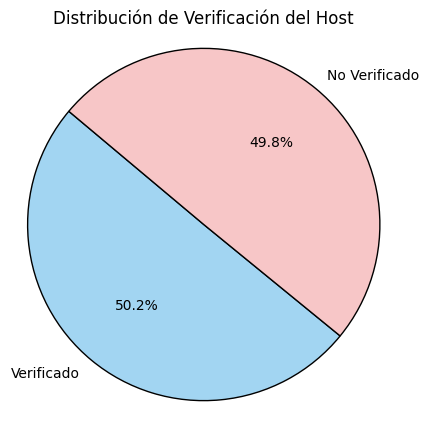

In [48]:
# --- PASO 1: HOST IDENTITY---

# Verificación de 'host_identity_verified'
verificacion_host = df['host_identity_verified'].value_counts()

print(df['host_identity_verified'].value_counts())

# Estética Gráfico de barras
plt.figure(figsize=(5,5))
plt.pie(
    verificacion_host,
    labels=['Verificado', 'No Verificado'],
    autopct='%1.1f%%',
    colors=['#A2D5F2', '#F7C6C7'],  # Colores pasteles
    startangle=140,
    wedgeprops={'edgecolor': 'black'}
)

# Grid y estilo
plt.title('Distribución de Verificación del Host')
plt.axis('equal')
plt.show()

# **2- Cantidad de alojamientos con estado de verificación del host por 'neighbourhood group' (host_identity_verified)**

Gráfico de Torta → ***¿Cuántos hosts tienen identidad verificada por 'neighbourhood group'?***

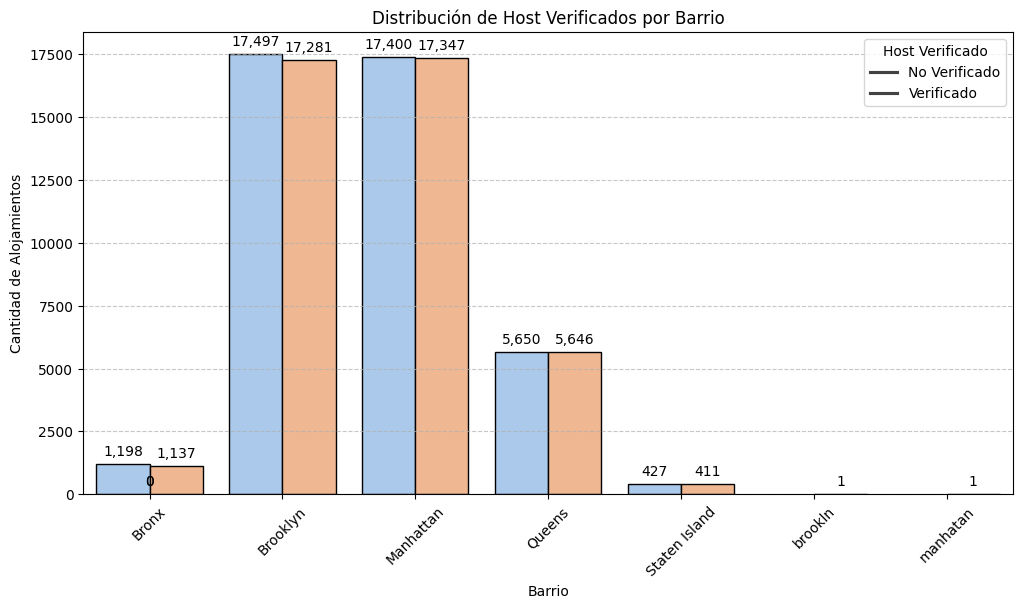

In [49]:
# --- PASO 2: HOST IDENTITY---

# Filtro para obviar 'Unspecified' de 'neighbourhood group'
df_filtrado = df[df['neighbourhood group'] != 'Unspecified']

# Agrupar y contar host verificados por neighbourhood group
host_verificado_por_barrio = df_filtrado.groupby(['neighbourhood group', 'host_identity_verified']).size().reset_index(name='count')

# Estética Gráfico de barras
plt.figure(figsize=(12,6))
sns.barplot(
    data=host_verificado_por_barrio,
    x='neighbourhood group',
    y='count',
    hue='host_identity_verified',
    palette='pastel',
    edgecolor='black'
)

# Agregar % sobre las barras
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():,.0f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       fontsize=10, color='black',
                       xytext=(0, 9), textcoords='offset points')

# Grid y estilo
plt.title('Distribución de Host Verificados por Barrio')
plt.xlabel('Barrio')
plt.ylabel('Cantidad de Alojamientos')
plt.legend(title='Host Verificado', labels=['No Verificado', 'Verificado'])
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# **Parte 5- Visualización: Análisis de Alojamiento**

# **1- Distribución de Precios de Alojamiento**

Histograma → ***Ver cómo se distribuyen los precios de los alojamientos.***

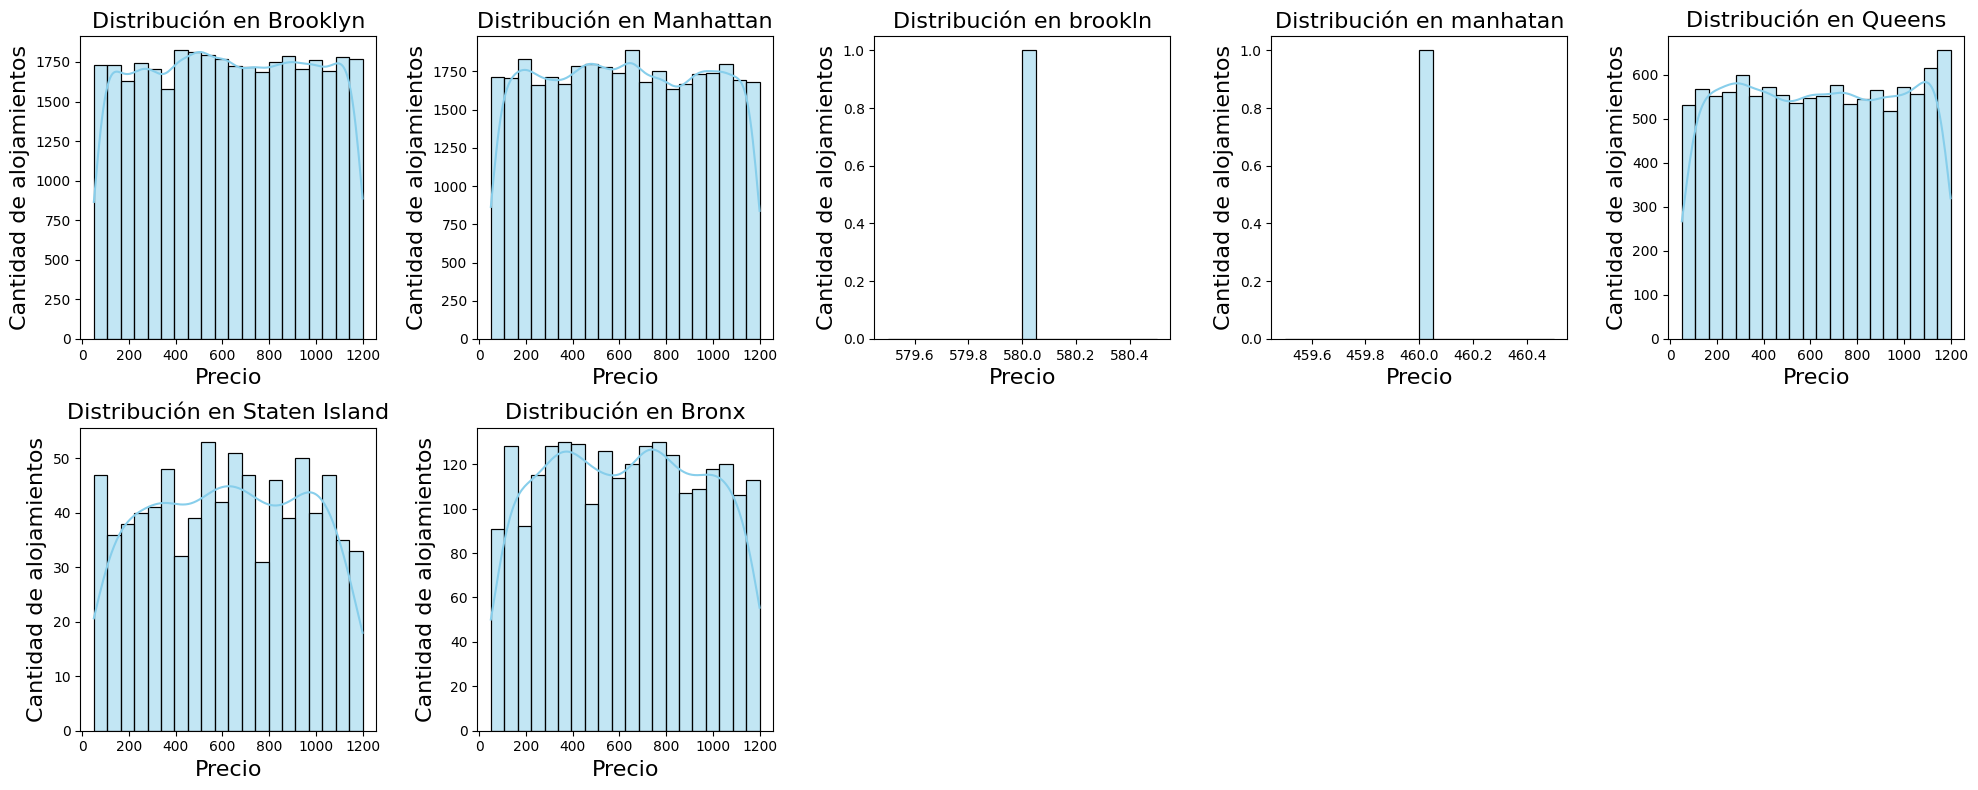

In [50]:
# --- PASO 1: DISTRIBUCIÓN DE PREIOS DE ALOJAMIENTO---

# Barrios
barrios = df['neighbourhood group'].unique()
barrios = df[df['neighbourhood group'] != 'Unspecified']['neighbourhood group'].unique()

# Filas y columnas necesarias
n_barrios = len(barrios)
n_cols = 5
n_rows = np.ceil(n_barrios / n_cols).astype(int)

# Estética del Histograma
plt.figure(figsize=(n_cols * 4, n_rows * 4))
for i, barrio in enumerate(barrios, 1):
    plt.subplot(n_rows, n_cols, i)  # Subgráficos dinámicamente

    # Filtro para no incluir 'Unspecified'
    data_to_plot = df[(df['neighbourhood group'] == barrio) & (df['price'] != 'Unspecified')]['price'].astype(float)

    sns.histplot(data_to_plot, kde=True, bins=20, color="skyblue", edgecolor="black")
    plt.title(f'Distribución en {barrio}', fontsize=16)
    plt.xlabel('Precio', fontsize=16)
    plt.ylabel('Cantidad de alojamientos', fontsize=16)

# Grid y estilo

plt.tight_layout()
plt.show()



# **2- Relación entre Precio y Número de Reseñas**

Gráfico de dispersión → ***¿Que relacion hay entre el precio y el número de reseñas?***

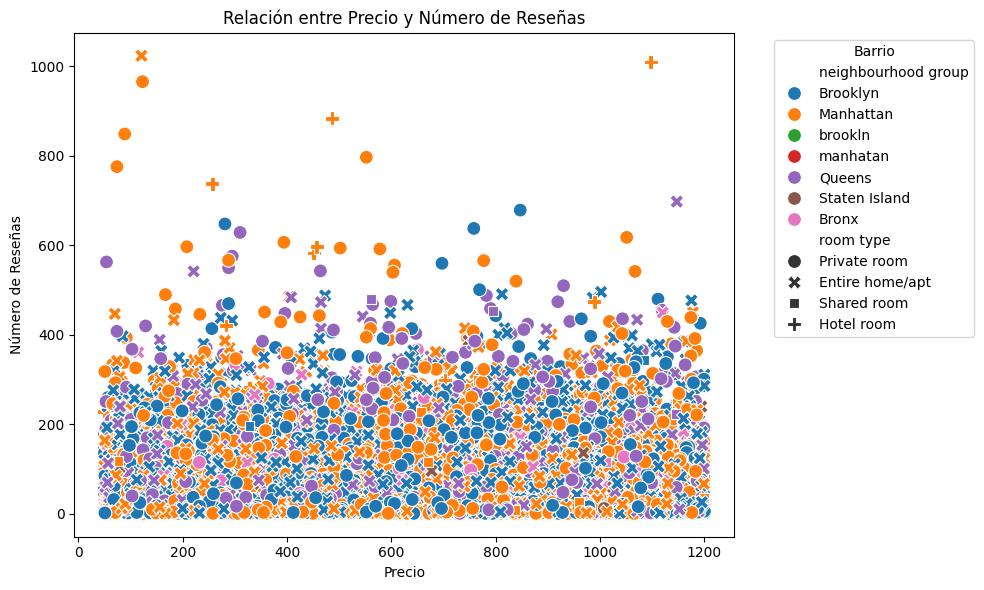

In [51]:
# --- PASO 2: RELACIÓN PRECIO/RESEÑA---

# Ajuste del DataFrame
df = df[df['price'] != 'Unspecified']
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df[df['neighbourhood group'] != 'Unspecified']

# Estética del Gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='price', y='number of reviews', hue='neighbourhood group', style='room type', s=100)

# Grid y estilo
plt.title('Relación entre Precio y Número de Reseñas')
plt.xlabel('Precio')
plt.ylabel('Número de Reseñas')
plt.legend(title='Barrio', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# **3- Evolución Mensual de Reseñas y Precios a lo Largo del Año**

Gráfico de líneas → ***¿Como se distribuyen las reseñas y el precio a lo largo del año?***

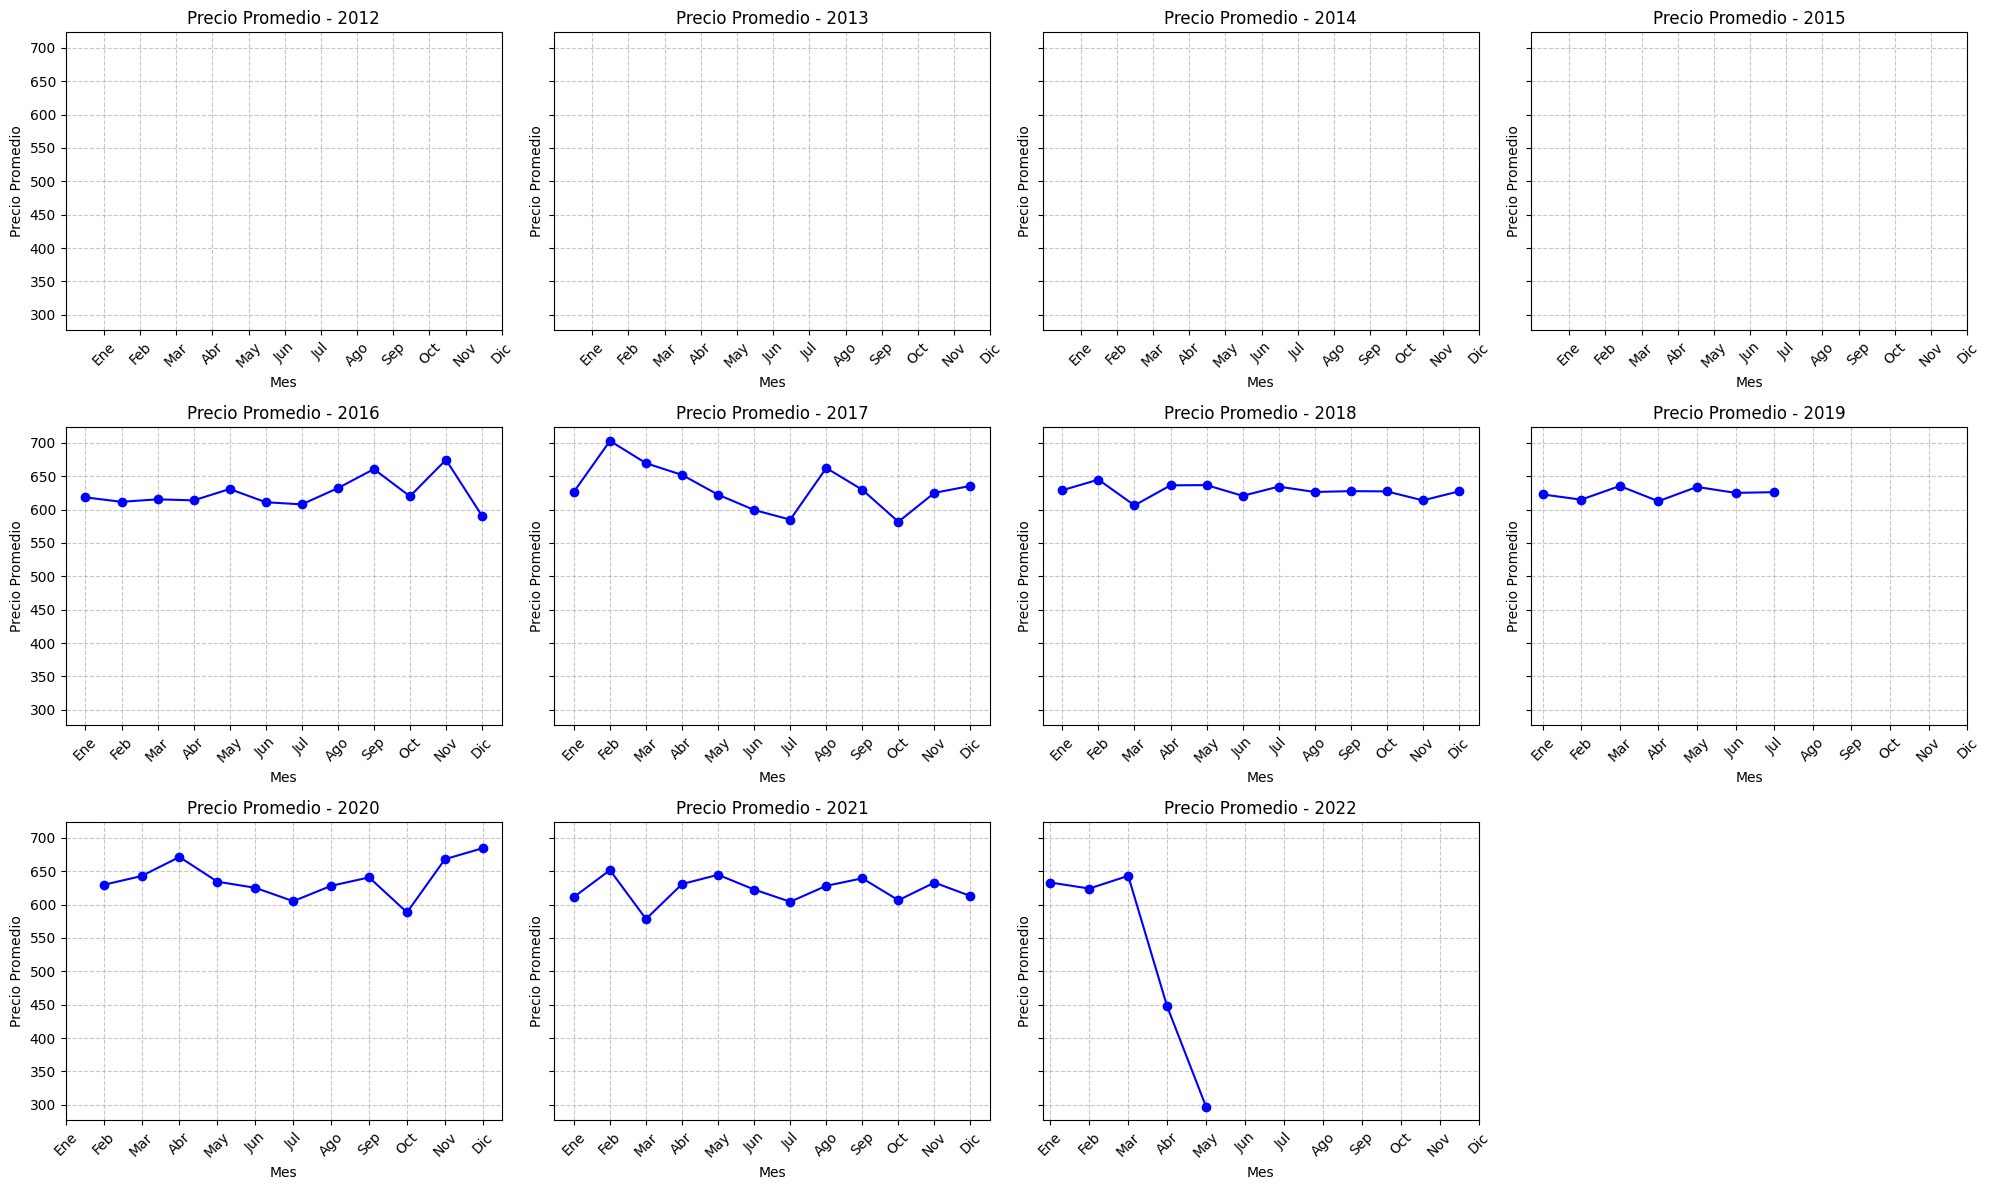

In [52]:
# --- PASO 3: PRECIO A LO LARGO DEL AÑO/EVOLUCIÓN MENSUAL DE RESEÑA---

# Ajuste del DataFrame
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')
df['year'] = df['last review'].dt.year
df['month'] = df['last review'].dt.month

# Lista de los años que se Visualizaran
years = [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

# Grilla para subplots
n_cols = 4
n_rows = math.ceil(len(years) / n_cols)
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, n_rows * 4), sharey=True)

axes = axes.flatten()

# Precio Promedio por mes
for i, year in enumerate(years):
    ax = axes[i]
    df_year = df[df['year'] == year]

    monthly_avg = df_year.groupby('month').agg({'price': 'mean'}).reset_index()

    ax.plot(monthly_avg['month'], monthly_avg['price'], marker='o', color='blue')
    ax.set_title(f'Precio Promedio - {year}')
    ax.set_xlabel('Mes')
    ax.set_ylabel('Precio Promedio')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'], rotation=45)
    ax.grid(True, linestyle='--', alpha=0.7)

# Eliminar ejes vacíos si hay
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Grid y estilo
plt.tight_layout()
plt.show()


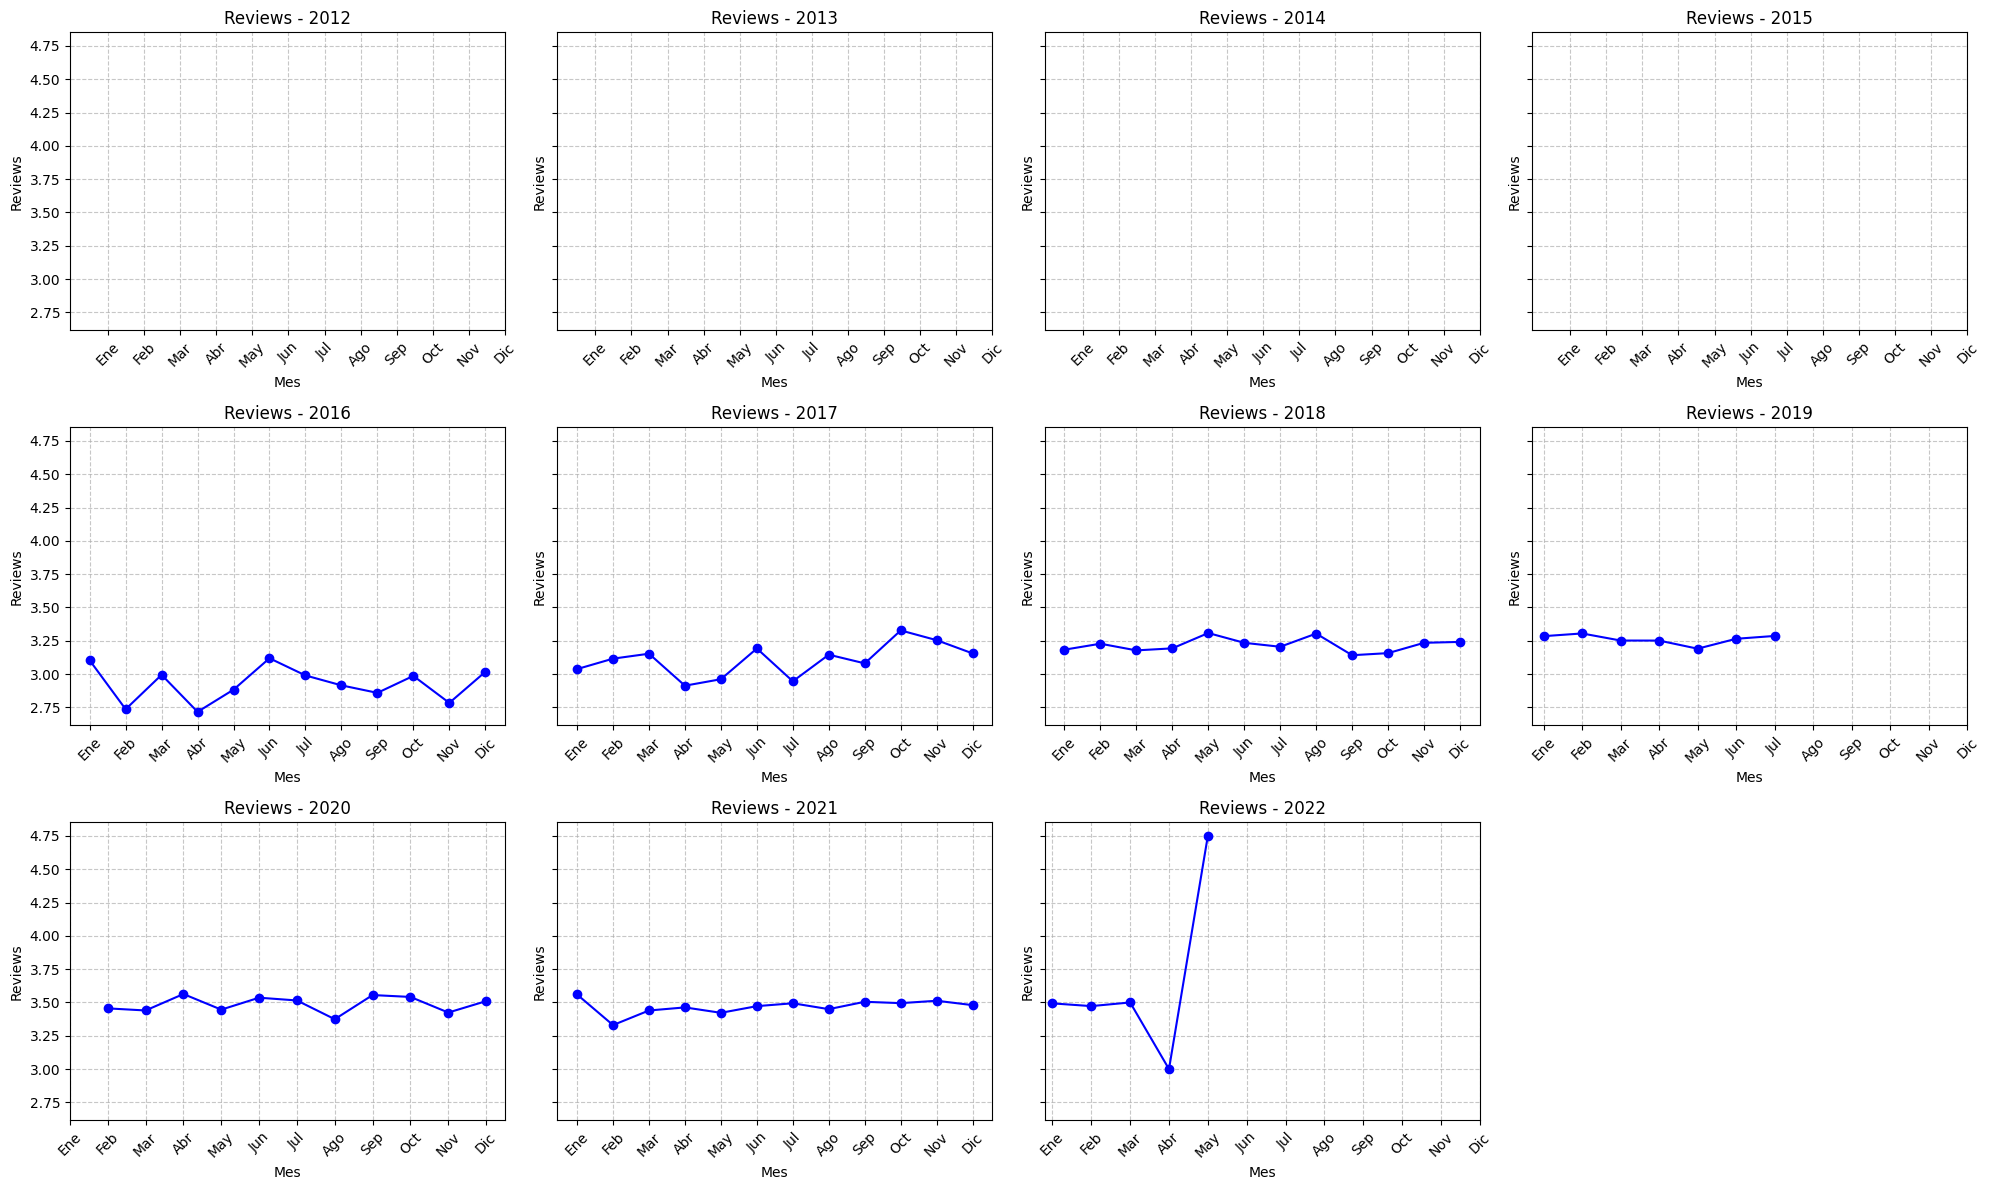

In [53]:
# --- PASO 4: PRECIO A LO LARGO DEL AÑO/EVOLUCIÓN MENSUAL DE RESEÑA---

# Ajuste del DataFrame
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')
df['year'] = df['last review'].dt.year
df['month'] = df['last review'].dt.month

# Lista de los años que se Visualizaran
years = [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

# Grilla para subplots
n_cols = 4
n_rows = math.ceil(len(years) / n_cols)
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, n_rows * 4), sharey=True)

axes = axes.flatten()

# Reviews por mes
for i, year in enumerate(years):
    ax = axes[i]
    df_year = df[df['year'] == year]

    monthly_avg = df_year.groupby('month').agg({'review rate number': 'mean'}).reset_index()

    ax.plot(monthly_avg['month'], monthly_avg['review rate number'], marker='o', color='blue')
    ax.set_title(f'Reviews - {year}')
    ax.set_xlabel('Mes')
    ax.set_ylabel('Reviews')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'], rotation=45)
    ax.grid(True, linestyle='--', alpha=0.7)

# Eliminar ejes vacíos si hay
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Grid y estilo
plt.tight_layout()
plt.show()

# **4- Relación entre Tipo de Habitación y Precio**

Grafico de lineas →  ***¿Que barrio tiene las mejores reseñas y en que mes?***

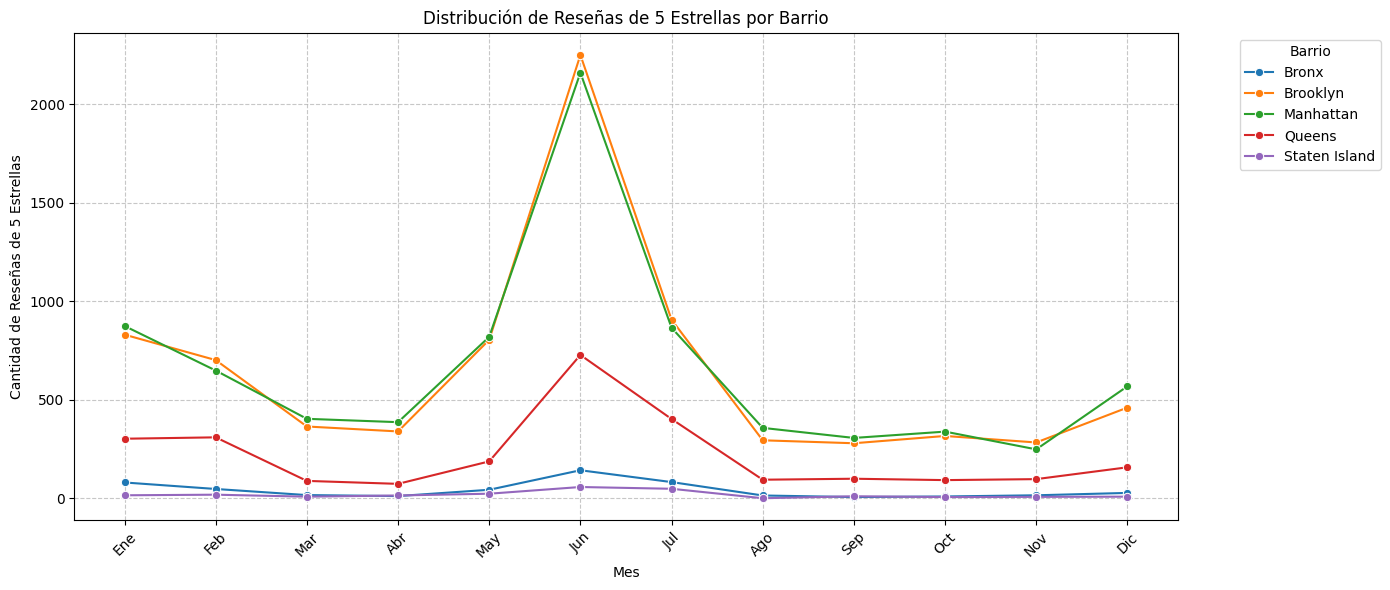

In [54]:
# --- PASO 5: TIPO DE HABITACION Y PRECIO---

# Filtrar los datos para seleccionar solo las reseñas de 5 estrellas
df_5stars = df[df['review rate number'] == 5].copy()
df_5stars['month'] = df_5stars['last review'].dt.month
df_5stars_grouped = df_5stars.groupby(['neighbourhood group', 'month']).size().reset_index(name='count')

# Estetica del Gráfico de líneas
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_5stars_grouped, x='month', y='count', hue='neighbourhood group', marker='o')

# Grid y estilo
plt.title('Distribución de Reseñas de 5 Estrellas por Barrio')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Reseñas de 5 Estrellas')
plt.xticks(range(1, 13), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'], rotation=45)
plt.legend(title='Barrio', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# **PARTE 5- Análisis de Propiedades en Alquiler**

**¿Cuáles son los patrones clave en precios, disponibilidad y reseñas?**

**Interpretación:** En este análisis, hemos examinado diversas visualizaciones para identificar tendencias en la distribución de precios, la variabilidad de la disponibilidad, y cómo las reseñas afectan la percepción de las propiedades. Al explorar estos patrones, buscamos entender cómo factores como la ubicación, tipo de propiedad y la puntuación de reseñas impactan en las decisiones de alquiler. Los insights obtenidos ayudarán a ajustar estrategias de precios, marketing y segmentación de clientes.

--- Asegurando que los tipos de datos son correctos ---
Tipo de 'price': float64
Tipo de 'availability 365': float64
Usando la columna 'review rate number' para la puntuación de reseñas.


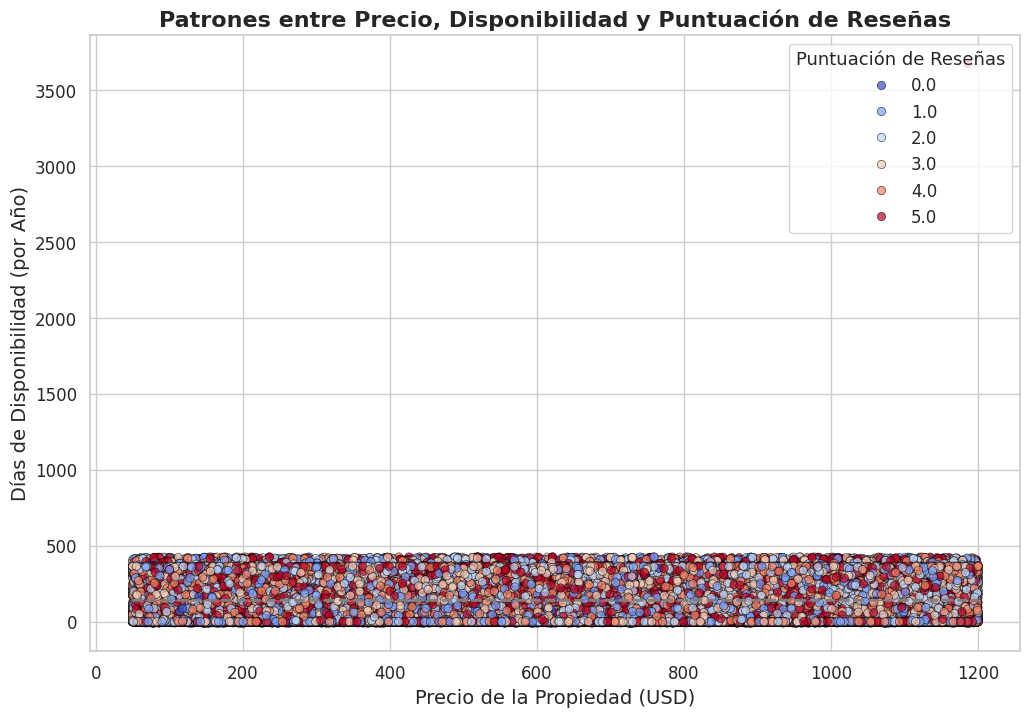

In [56]:
# --- PASO 1: ANÁLISIS DE PROPIEDADES EN ALQUILER (CORREGIDO) ---

import seaborn as sns
import matplotlib.pyplot as plt

# --- A. PREPARACIÓN DE DATOS (Asegurarse de que las columnas son numéricas) ---
# Esta parte es crucial y soluciona el error.
print("--- Asegurando que los tipos de datos son correctos ---")

# Convierte 'price' a numérico (forzando errores a NaN)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
# Convierte 'availability 365' a numérico
df['availability 365'] = pd.to_numeric(df['availability 365'], errors='coerce')

# Elimina las filas donde el precio o la disponibilidad sean NaN (necesario para regplot)
df_limpio = df.dropna(subset=['price', 'availability 365'])
print(f"Tipo de 'price': {df_limpio['price'].dtype}")
print(f"Tipo de 'availability 365': {df_limpio['availability 365'].dtype}")


# --- B. CÓDIGO DE VISUALIZACIÓN ---
# Configurar estilo
sns.set(style='whitegrid')

# Crear gráfico
plt.figure(figsize=(12, 8))

# Identificar la columna de calificación (tu código es excelente para esto)
rating_column = 'review_scores_rating'
if rating_column not in df_limpio.columns:
    potential_rating_columns = ['review_rate_number', 'review rate number', 'review_score', 'rating']
    for col in potential_rating_columns:
        # Nos aseguramos de que la columna exista y sea numérica
        if col in df_limpio.columns and pd.api.types.is_numeric_dtype(df_limpio[col]) and df_limpio[col].max() <= 5:
            rating_column = col
            break
    else:
        print("Advertencia: No se encontró una columna adecuada para la calificación de reseñas (1-5). El gráfico no usará colores.")
        rating_column = None

if rating_column:
    print(f"Usando la columna '{rating_column}' para la puntuación de reseñas.")
    scatter = sns.scatterplot(
        data=df_limpio,
        x='price',
        y='availability 365',
        hue=rating_column,
        palette='coolwarm',
        alpha=0.7,
        edgecolor='black'
    )
    plt.legend(title='Puntuación de Reseñas', fontsize=12, title_fontsize=13, loc='upper right')


    # Opcional: Agregar línea de tendencia
    # sns.regplot solo funciona bien si el 'hue' no es muy complejo.
    # Vamos a dibujarlo sin 'hue' para ver la tendencia general.
    sns.regplot(
        data=df_limpio,
        x='price',
        y='availability 365',
        scatter=False, # Importante: no redibujar los puntos
        color='gray',
        line_kws={'linestyle': '--', 'linewidth': 2}
    )

    # Títulos y etiquetas
    plt.title('Patrones entre Precio, Disponibilidad y Puntuación de Reseñas', fontsize=16, fontweight='bold')
    plt.xlabel('Precio de la Propiedad (USD)', fontsize=14)
    plt.ylabel('Días de Disponibilidad (por Año)', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # Mostrar gráfico
    plt.show()
else:
    print("No se pudo generar el gráfico porque no se encontró una columna de calificación válida.")

In [57]:
print(df_filtrado['availability 365'].describe())

count     83831.0
unique      438.0
top           0.0
freq      17812.0
Name: availability 365, dtype: float64


# **6- Distribución de Precios**

**¿Cuál es el rango de precios en el dataset y cuáles son los precios más comunes? ¿Cómo se distribuyen los precios por tipo de propiedad o barrio?**

**Interpretación:** Si el histograma muestra que la mayoría de los precios están concentrados en un rango específico (por ejemplo, entre $50 y $150), eso indica que la mayoría de las propiedades en el dataset están en ese rango de precios, lo que puede ser útil para una estrategia de precios en una plataforma de alquiler.

La distribución de precios permite identificar si el mercado está más centrado en propiedades de bajo costo, medio o alto precio, y cómo podrían afectarse las estrategias de precios o la segmentación de los clientes en función de este rango.


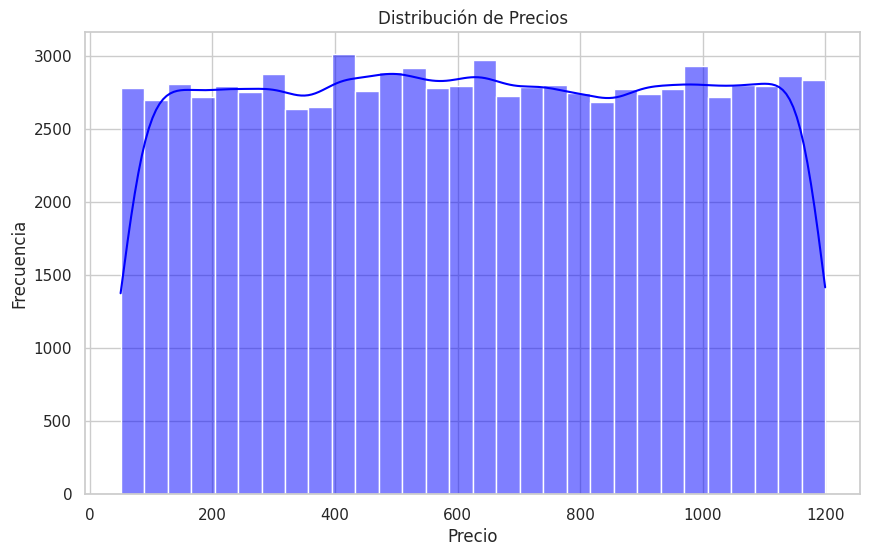

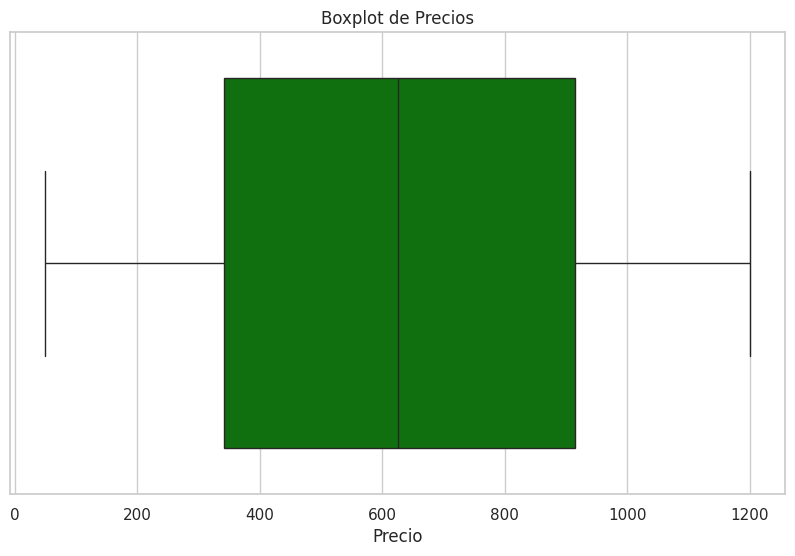

In [58]:
# Histograma de precios
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=30, color='blue')
plt.title('Distribución de Precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

# Boxplot de precios
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['price'], color='green')
plt.title('Boxplot de Precios')
plt.xlabel('Precio')
plt.show()

# **7- Comparación por Barrio**

**¿Cuáles son los barrios o grupos de barrios más caros o más baratos? ¿Existen patrones claros en cuanto a la ubicación y el precio?**

**Interpretación:** Si algunos barrios tienen precios consistentemente más altos, se podría concluir que esos son áreas con más demanda o propiedades de mayor calidad.
Esta información es clave para tomar decisiones sobre dónde invertir o qué barrios promover más en la plataforma.

Vinculación con la pregunta: Este gráfico es útil para entender las diferencias de precios entre barrios y puede guiar estrategias de marketing o segmentación geográfica.

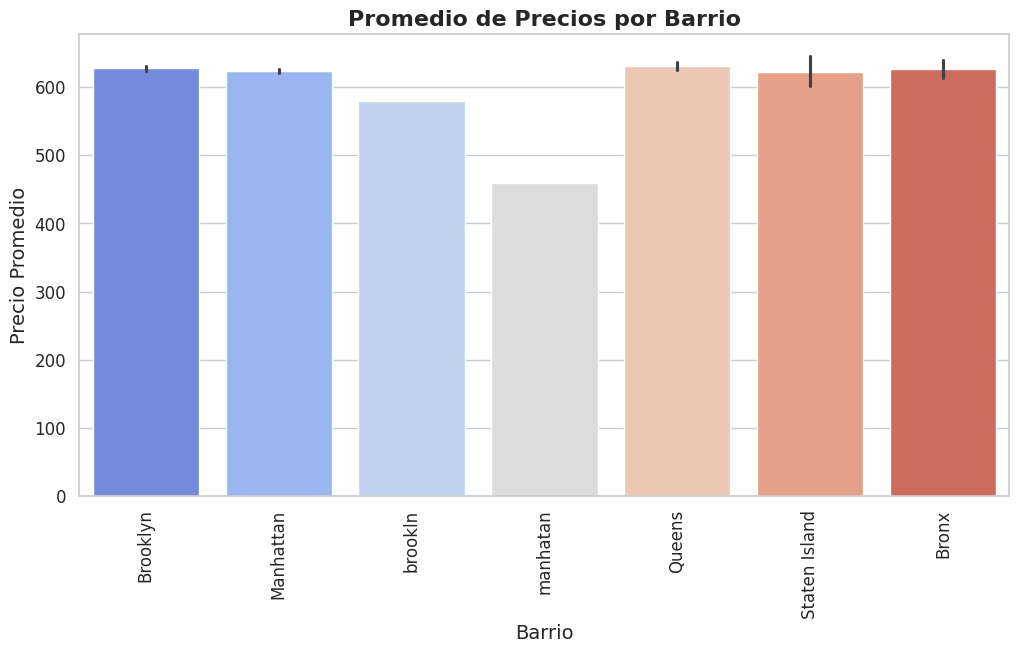

In [59]:
# Promedio de precios por barrio
plt.figure(figsize=(12, 6))
sns.barplot(
    x='neighbourhood group',  # Changed to 'neighbourhood group'
    y='price',
    data=df,
    hue='neighbourhood group',  # Changed to 'neighbourhood group'
    palette='coolwarm',
    legend=False
)
plt.title('Promedio de Precios por Barrio', fontsize=16, fontweight='bold')
plt.xlabel('Barrio', fontsize=14)
plt.ylabel('Precio Promedio', fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# **8- Disponibilidad 365**

**¿Cuánto tiempo están disponibles las propiedades en un año? ¿Cuál es la variabilidad en la disponibilidad de las propiedades?**

**Interpretación:** Si la mayoría de las propiedades tienen un valor cercano a 365, eso sugiere que están disponibles durante todo el año. Si muchas propiedades tienen una disponibilidad baja (por ejemplo, menos de 100 días), eso podría indicar que están disponibles solo durante temporadas específicas.

La disponibilidad de las propiedades podría estar relacionada con la demanda en diferentes temporadas del año, lo que ayudaría a definir estrategias de marketing o promociones basadas en la temporada.

**Vinculación con la pregunta:** Analizar la disponibilidad temporal es crucial para ajustar la estrategia de precios y disponibilidad de las propiedades, alineándolas con las expectativas de los clientes en diferentes momentos del año.

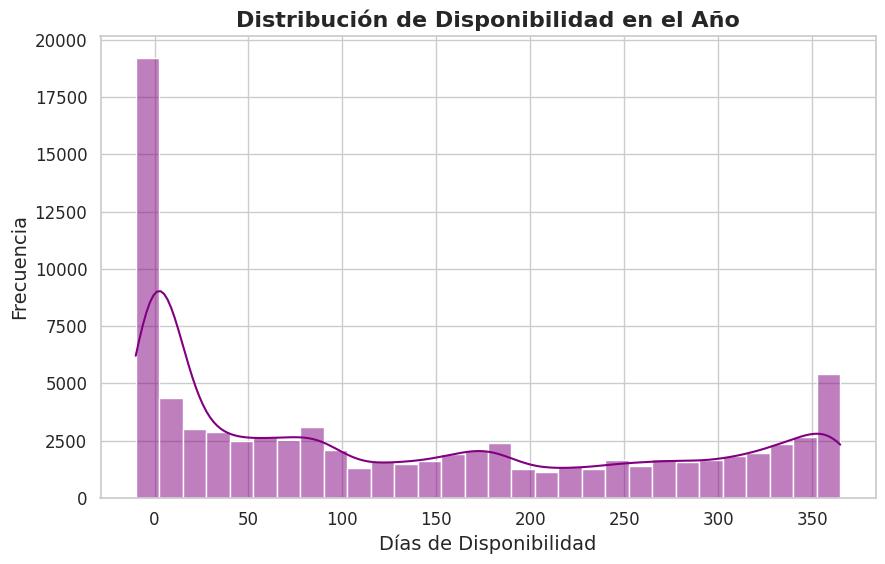

In [60]:
# Filtro solo alojamiento con disponibilidad entre 0 y 365 dias
df_filtered = df[df['availability 365'] <= 365]

# Histograma de disponibilidad
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_filtered,
    x='availability 365',  # <- Cambié aquí el nombre
    kde=True,
    bins=30,
    color='purple'
)
plt.title('Distribución de Disponibilidad en el Año', fontsize=16, fontweight='bold')
plt.xlabel('Días de Disponibilidad', fontsize=14)
plt.ylabel('Frecuencia', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# **9- Comparación por Tipo de Propiedad**

**¿Cómo varían los precios según el tipo de propiedad?**

**Interpretación:** Es probable que las casas o propiedades más grandes tengan precios más altos que los apartamentos más pequeños. Sin embargo, el tipo de propiedad también podría estar vinculado a la ubicación (por ejemplo, los apartamentos en el centro pueden ser más caros que las casas más grandes en las afueras).

Este gráfico ofrece insights clave para comprender cómo se segmentan los precios en función del tipo de propiedad y puede guiar a los usuarios o propietarios sobre qué tipo de propiedades podrían tener más éxito en términos de rentabilidad.

**Vinculación con la pregunta:** Ayuda a identificar patrones de precios basados en el tipo de propiedad, lo que puede influir en la estrategia de alquiler y segmentación de los clientes.

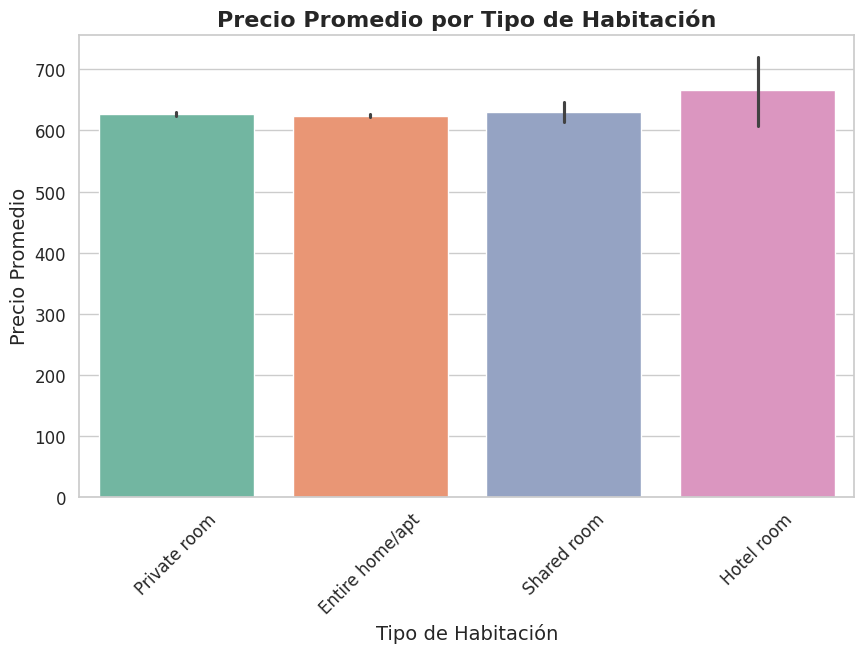

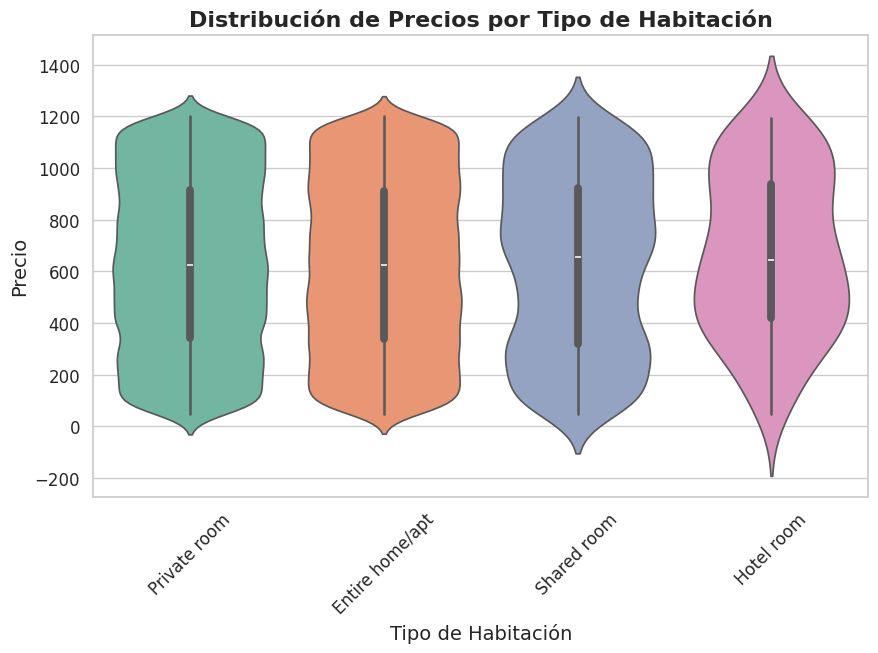

In [61]:
# Gráfico de barras con precio medio por tipo de habitación
plt.figure(figsize=(10, 6))
sns.barplot(x='room type', y='price', hue='room type', data=df, palette='Set2', legend=False)
plt.title('Precio Promedio por Tipo de Habitación', fontsize=16, fontweight='bold')
plt.xlabel('Tipo de Habitación', fontsize=14)
plt.ylabel('Precio Promedio', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Alternativamente, un gráfico de violín para comparar la distribución de precios por tipo de habitación
plt.figure(figsize=(10, 6))
sns.violinplot(x='room type', y='price', hue='room type', data=df, palette='Set2', legend=False)
plt.title('Distribución de Precios por Tipo de Habitación', fontsize=16, fontweight='bold')
plt.xlabel('Tipo de Habitación', fontsize=14)
plt.ylabel('Precio', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# **10- Análisis de la Evolución Temporal de las Reseñas**

**¿Cómo ha evolucionado la calidad de las propiedades o la satisfacción del cliente con el tiempo?**

**Interpretación:** Si las puntuaciones de reseñas aumentan con el tiempo, puede indicar que los propietarios están mejorando la calidad de sus propiedades o servicios. Una caída en las puntuaciones puede reflejar problemas recurrentes o cambios en las expectativas de los huéspedes.

Este análisis temporal permite observar las tendencias de satisfacción a lo largo del tiempo y prever áreas donde puede ser necesario hacer mejoras.

**Vinculación con la pregunta:** Analizar la evolución temporal de las reseñas es crucial para identificar si las mejoras o deterioros en la calidad de las propiedades afectan la satisfacción de los huéspedes.

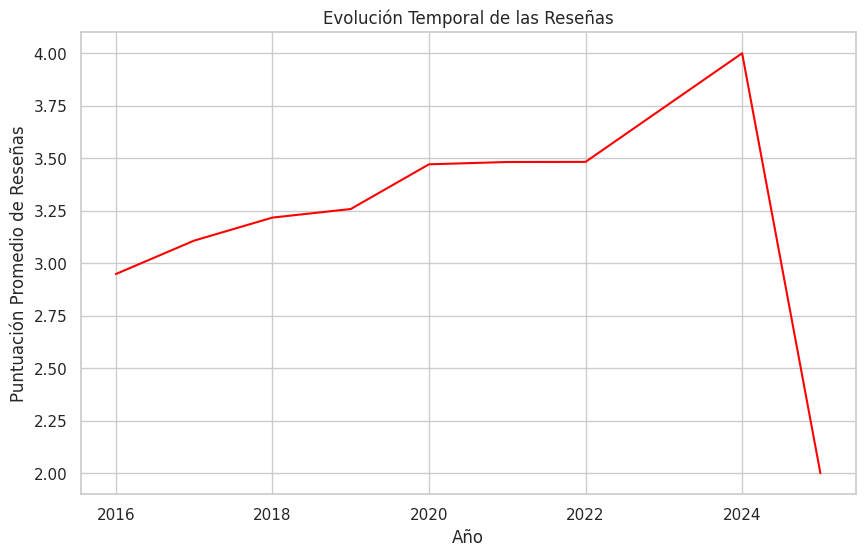

In [62]:
# Convertir la columna 'last review' a formato datetime
df['last review'] = pd.to_datetime(df['last review'])

# Agrupar por año y calcular la puntuación promedio
df['year'] = df['last review'].dt.year
average_rating_per_year = df.groupby('year')['review rate number'].mean()

# Gráfico de líneas de la evolución de las puntuaciones
plt.figure(figsize=(10, 6))
sns.lineplot(x=average_rating_per_year.index, y=average_rating_per_year.values, color='red')
plt.title('Evolución Temporal de las Reseñas')
plt.xlabel('Año')
plt.ylabel('Puntuación Promedio de Reseñas')
plt.show()